# PRCP-1023 : Johns Hopkins COVID-19 Prediction

## Domain
Healthcare

---

# Problem Statement

The COVID-19 pandemic has significantly impacted public health systems, economies, and daily life worldwide. Accurate forecasting of future COVID-19 cases enables governments and healthcare organizations to prepare medical resources, strengthen healthcare infrastructure, and implement timely preventive measures.

The objective of this project is to analyze historical COVID-19 data provided by the Johns Hopkins University Center for Systems Science and Engineering (JHU CSSE), identify meaningful trends, build predictive models for forecasting future confirmed cases, and provide data-driven recommendations to healthcare authorities.

---

# Project Objectives

- Perform comprehensive exploratory data analysis (EDA).
- Understand historical trends of COVID-19 confirmed cases.
- Prepare the dataset for machine learning.
- Build multiple predictive models.
- Compare model performances using appropriate evaluation metrics.
- Forecast future COVID-19 confirmed cases.
- Provide recommendations for government health departments based on the predictions.

---

# Project Workflow

1. Import Required Libraries
2. Load the Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Data Preprocessing
8. Model Building
9. Hyperparameter Tuning
10. Model Evaluation
11. Future Forecasting
12. Government Recommendations
13. Challenges Faced
14. Final Conclusion

In [1]:
# PRCP-1023 : Johns Hopkins COVID-19 Prediction
# Step 1 : Import Required Libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time Utilities
from datetime import datetime, timedelta

# Machine Learning Utilities
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All required libraries imported successfully.")

All required libraries imported successfully.


# Step 2: Load and Understand the Dataset

## Objective

Before performing any analysis or building predictive models, it is essential to understand the structure and quality of the dataset.

The COVID-19 dataset used in this project is provided by the **Johns Hopkins University Center for Systems Science and Engineering (JHU CSSE)**. It contains daily cumulative records of confirmed cases, deaths, and recovered cases reported across different countries and regions worldwide.

In this step, we will:

- Load all available datasets into Pandas DataFrames.
- Verify that the datasets are loaded successfully.
- Examine the dimensions of each dataset.
- Inspect the first few records.
- Understand the meaning of each column.
- Identify the overall structure before data preprocessing.

This initial exploration helps ensure the data is complete, correctly formatted, and suitable for further analysis.

In [2]:
# Step 2.1 : Load the Dataset

# Load the COVID-19 datasets

confirmed_df = pd.read_csv("time_series_covid19_confirmed_global.csv")
deaths_df = pd.read_csv("time_series_covid19_deaths_global.csv")
recovered_df = pd.read_csv("time_series_covid19_recovered_global.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


## Dataset Dimensions

The shape of a dataset represents the number of rows and columns it contains.

- **Rows** represent observations (countries or regions).
- **Columns** represent variables or features.

Checking the dimensions allows us to verify that the datasets have been imported correctly and provides an overview of the dataset size.

In [3]:
# Step 2.2 : Check Dataset Dimensions

print("Confirmed Cases Dataset Shape :", confirmed_df.shape)
print("Deaths Dataset Shape          :", deaths_df.shape)
print("Recovered Dataset Shape       :", recovered_df.shape)

Confirmed Cases Dataset Shape : (266, 248)
Deaths Dataset Shape          : (266, 248)
Recovered Dataset Shape       : (253, 248)


## Preview the Dataset

The `head()` function displays the first five records of the dataset.

Previewing the dataset helps us:

- Understand the overall layout.
- Identify important columns.
- Verify that the data has been loaded correctly.
- Observe how COVID-19 statistics are stored.

In [4]:
# Step 2.3 : Display First Five Records

print("Confirmed Cases Dataset")
display(confirmed_df.head())

print("Deaths Dataset")
display(deaths_df.head())

print("Recovered Dataset")
display(recovered_df.head())

Confirmed Cases Dataset


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,5,7,7,7,11,16,21,22,22,22,24,24,40,40,74,84,94,110,110,120,170,174,237,273,281,299,349,367,423,444,484,521,555,607,665,714,784,840,906,933,996,1026,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171,2335,2469,2704,2894,3224,3392,3563,3778,4033,4402,4687,4963,5226,5639,6053,6402,6664,7072,7653,8145,8676,9216,9998,10582,11173,11831,12456,13036,13659,14525,15205,15750,16509,17267,18054,18969,19551,20342,20917,21459,22142,22890,23546,24102,24766,25527,26310,26874,27532,27878,28424,28833,29157,29481,29640,30175,30451,30616,30967,31238,31517,31836,32022,32324,32672,32951,33190,33384,33594,33908,34194,34366,34451,34455,34740,34994,35070,35229,35301,35475,35526,35615,35727,35928,35981,36036,36157,36263,36368,36471,36542,36675,36710,36710,36747,36782,36829,36896,37015,37054,37054,37162,37269,37345,37424,37431,37551,37596,37599,37599,37599,37856,37894,37953,37999,38054,38070,38113,38129,38140,38143,38162,38165,38196,38243,38288,38304,38324,38398,38494,38520,38544,38572,38606,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,10,12,23,33,38,42,51,55,59,64,70,76,89,104,123,146,174,186,197,212,223,243,259,277,304,333,361,377,383,400,409,416,433,446,467,475,494,518,539,548,562,584,609,634,663,678,712,726,736,750,766,773,782,789,795,803,820,832,842,850,856,868,872,876,880,898,916,933,946,948,949,964,969,981,989,998,1004,1029,1050,1076,1099,1122,1137,1143,1164,1184,1197,1212,1232,1246,1263,1299,1341,1385,1416,1464,1521,1590,1672,1722,1788,1838,1891,1962,1995,2047,2114,2192,2269,2330,2402,2466,2535,2580,2662,2752,2819,2893,2964,3038,3106,3188,3278,3371,3454,3571,3667,3752,3851,3906,4008,4090,4171,4290,4358,4466,4570,4637,4763,4880,4997,5105,5197,5276,5396,5519,5620,5750,5889,6016,6151,6275,6411,6536,6676,6817,6971,7117,7260,7380,7499,7654,7812,7967,8119,8275,8427,8605,8759,8927,9083,9195,9279,938

Deaths Dataset


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,2,4,4,4,4,4,4,4,6,6,7,7,11,14,14,15,15,18,18,21,23,25,30,30,30,33,36,36,40,42,43,47,50,57,58,60,64,68,72,85,90,95,104,106,109,115,120,122,127,132,136,153,168,169,173,178,187,193,205,216,218,219,220,227,235,246,249,257,265,270,294,300,309,327,357,369,384,405,426,446,451,471,478,491,504,546,548,569,581,598,618,639,675,683,703,721,733,746,774,807,819,826,864,898,920,936,957,971,994,1010,1012,1048,1094,1113,1147,1164,1181,1185,1186,1190,1211,1225,1248,1259,1269,1270,1271,1271,1272,1283,1284,1288,1288,1294,1298,1307,1312,1312,1328,1344,1354,1363,1363,1370,1375,1375,1375,1375,1385,1385,1385,1387,1389,1397,1401,1401,1402,1402,1402,1402,1406,1409,1409,1409,1409,1412,1415,1418,1420,1420,1420,1420,1420,1425,1426,1436,1436,1437,1437,1441,1444
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,2,2,2,2,2,4,5,5,6,8,10,10,11,15,15,16,17,20,20,21,22,22,23,23,23,23,23,24,25,26,26,26,26,26,26,27,27,27,27,28,28,30,30,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,32,32,33,33,33,33,33,33,33,33,33,33,33,34,34,34,34,34,35,36,36,36,36,37,38,39,42,43,44,44,45,47,49,51,53,55,58,62,65,69,72,74,76,79,81,83,83,85,89,93,95,97,101,104,107,111,112,113,117,120,123,128,134,138,144,148,150,154,157,161,166,172,176,182,188,189,193,199,200,205,208,213,219,225,228,230,232,234,238,240,245,250,254,259,263,266,271,275,280,284,290,296,301,306,312,316,319,321,322,324,327,330,334,338,340,343,347,353,358,362,364
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,3,4,4,4,7,9,11,15,17,17,19,21,25,26,29,31,35,44,58,86,105,130,152,173,193,205,235,256,275,293,313,326,336,348,364,367,375,384,392,402,407,415,419,425,432,437,444,450,453,459,463,465,470,476,483,488,494,502,507,515,522,529,536,542,548,555,561,568,575,582,592,600,609,617,6

Recovered Dataset


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,5,5,10,10,10,15,18,18,29,32,32,32,32,32,40,43,54,99,112,131,135,150,166,179,188,188,207,220,228,252,260,310,331,345,397,421,458,468,472,502,558,558,610,648,691,745,745,778,801,850,930,938,996,1040,1075,1097,1128,1138,1209,1259,1303,1328,1428,1450,1522,1585,1762,1830,1875,2171,2651,3013,3326,3928,4201,4725,5164,5508,6158,7660,7962,8292,8764,8841,9260,9869,10174,10306,10674,12604,13934,14131,15651,16041,17331,19164,19366,20103,20179,20700,20847,20882,21135,21216,21254,21454,22456,22824,23151,23273,23634,23741,23741,23924,24550,24602,24793,25180,25198,25358,25389,25471,25509,25509,25510,25669,25669,25742,25840,25903,25960,25960,26228,26415,26694,26714,26714,27166,27166,27166,27166,27166,27681,28016,28016,28180,28360,28440,29042,29046,29059,29063,29089,29089,29231,29315,29390,29713,30082,30537,30557,30715,31048,31129,31154,31234,31638,32073,32098,32503,32505,32576,32576,32576,32576
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,2,10,17,17,31,31,33,44,52,67,76,89,99,104,116,131,154,165,182,197,217,232,248,251,277,283,302,314,327,345,356,385,394,403,410,422,431,455,470,488,519,531,543,570,595,605,620,627,650,654,682,688,694,705,714,715,727,742,758,771,777,783,789,795,803,812,823,851,857,872,877,891,898,898,910,925,938,945,960,980,1001,1034,1039,1044,1055,1064,1077,1086,1114,1126,1134,1159,1195,1217,1250,1298,1346,1384,1438,1459,1516,1559,1592,1637,1657,1702,1744,1791,1832,1875,1881,1946,2014,2062,2091,2137,2214,2264,2311,2352,2397,2463,2523,2608,2637,2682,2745,2789,2830,2883,2952,2961,3018,3031,3031,3123,3155,3227,3268,3342,3379,3480,3552,3616,3695,3746,3794,3816,3871,3928,3986,4096,4184,4332,4413,4530,4633,4791,4923,5020,5139,5214,5441,5582,5732,5882,5976,6106,6186,6239,6284,6346,6443,6494,6569,6615,6668,6733,6788,6831,6888,6940,6995
2,NaN,Algeria,28.03390,1.659600,0,0,0,

## Display the Last Five Records

The `tail()` function displays the last five records of the dataset.

Reviewing the last records helps verify that:

- The dataset is complete.
- The latest observations are available.
- No unexpected truncation occurred during loading.

In [5]:
# Step 2.4 : Display Last Five Records

print("Confirmed Cases Dataset")
display(confirmed_df.tail())

print("Deaths Dataset")
display(deaths_df.tail())

print("Recovered Dataset")
display(recovered_df.tail())

Confirmed Cases Dataset


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
261,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,7,16,16,19,26,30,30,31,35,38,38,39,41,44,47,48,52,59,59,59,84,91,98,109,116,119,134,161,194,217,237,254,261,263,263,267,268,271,273,284,291,294,307,313,319,329,329,335,336,340,342,342,342,343,344,344,353,353,353,362,371,374,375,375,375,375,375,375,375,375,375,376,381,388,391,398,423,423,423,423,423,429,434,446,446,447,448,449,451,457,464,464,464,472,473,481,485,487,489,489,492,505,514,555,600,675,784,833,1001,1169,1328,1382,1557,1815,1990,2185,2428,2758,3080,3334,3835,4277,4341,4647,5029,5220,5551,5931,6230,6566,6764,7064,7412,7764,8204,8549,8916,9228,9398,9744,10093,10306,10469,10621,10938,11284,11548,11837,12160,12297,12541,12770,13065,13398,13722,13928,14208,14510,14875,15184,15491,15834,16153,16534,16844,17306,17606,17989,18313,18476,18802,19213,19678,20155,20677,21251,21668,22204,22729,23281,23875,24471,25142,25575,26127,26779,27363,27919,28664,29256,29906,30574,31362,32250,33006,33843,34401,35003,35686,36151
262,NaN,Western Sahara,24.215500,-12.885800,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,4,4,4,4,4,4,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
263,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,6,6,7,10,10,12,22,25,25,34,34,51,56,65,70,85,106,122,128,130,167,184,197,209,212,222,233,249,256,278,283,310,323,354,399,419,453,469,482,484,496,524,560,591,632,70

Deaths Dataset


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
261,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,4,5,8,8,9,11,13,16,17,18,20,24,27,33,36,39,44,44,51,53,59,62,63,64,66,67,70,75,76,78,79,80,81,82,83,84,84,86,89,92,94,96,97,100,104,105,106,106,108,110,113,113,119,120,122,125,128,133,133,137,141,145,147,152,152,159,162,167,170,177,181,184,190,192,198,204,210,221,226,229,243,244,250,253,262,265
262,NaN,Western Sahara,24.215500,-12.885800,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
263,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,2,2,2,4,5,5,7,7,8,9,10,12,12,15,18,20,20,28,30,33,33,39,42,44,49,53,57,65,77,80,84,87,95,103,111,111,112,112,127,129,136,139,160,164,208,214,244,248,251,254,256,257,261,274,288,293,296,302,304,312,318,325,335,337,338,345,348,351,361,364,365,417,424,429,433,438,440,443,445,447,456,458,461,469,474,479,483,484,485,487,493,494,497,499,506,508,508,512,512,515,518,523,528,528,528,528,530,535,537,539,541,542,546,553,555,557,560,562,563,563,564,566,570,571,571,572,572,572,573,576,576,580,582,582,583,583,583,583,585,585,585,586,586
264,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

Recovered Dataset


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
248,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,17,17,17,17,17,17,17,18,18,18,18,18,18,21,21,25,24,42,44,44,45,57,58,58,62,63,63,69,69,71,71,71,71,74,81,83,83,83,71,71,76,76,76,77,102,127,174,176,228,228,263,301,308,310,310,315,329,335,337,346,346,346,346,348,357,357,365,365,368,368,368,372,372,372,372,377,377,400,403,404,404,410,410,414,415,415,415,415,415,415,437,437,439,442,442,442,446,446,446,447,447,451,460,460,463,463,491,491,494,494,525,536,536,942,1084,1084,1084,1313,1492,1596,1921,1921,1932,1950,2720,2720,3282,3752,3752,3752,4833,5016,5077,5324,5390,5390,6419,6618,6907,7210,7706,7945,8045,8181,8369,9186,9382,9388,9838,9906,9939,10312,10682,11102,11103,11843,11870,13162,13929,14194,14291,14631,14787,15056,15338,15483,16095,16437,16661,16843,17270,17779,18466,18821,19788,19979,20082,21406,21804,22209,23060,23333,23446,23700,24428
249,NaN,Western Sahara,24.215500,-12.885800,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
250,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,5,5,5,11,11,10,10,10,10,11,11,13,14,14,15,17,17,23,23,23,23,23,23,23,28,39,53,79,91,271,273,288,328,347,350,356,379,386,402,417,430,432,488,504,513,536,537,552,575,591,595,619,630,642,659,675,685,694,695,695,701,712,714,741,751,762,779,780,797,833,840,849,856,862,862,862,863,863,894,898,907,910,913,915,915,937

## Dataset Information

The `info()` function provides detailed information about the dataset, including:

- Number of rows and columns.
- Data types of each column.
- Number of non-null values.
- Memory usage.

This information is useful for identifying missing values and verifying that each feature has the correct data type before preprocessing.

In [6]:
# Step 2.5 : Dataset Information

print("Confirmed Dataset Information")
confirmed_df.info()

print("\n" + "="*100 + "\n")

print("Deaths Dataset Information")
deaths_df.info()

print("\n" + "="*100 + "\n")

print("Recovered Dataset Information")
recovered_df.info()

Confirmed Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


Deaths Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


Recovered Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 490.3+ KB


## Statistical Summary

The `describe()` function generates descriptive statistics for numerical columns.

It provides:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Quartiles (25%, 50%, 75%)
- Maximum Value

These statistics help us understand the numerical distribution of the dataset and identify potential outliers.

In [7]:
# Step 2.6 : Statistical Summary

display(confirmed_df.describe())
display(deaths_df.describe())
display(recovered_df.describe())

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.00000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.00000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.00000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.0

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.00000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000e+02,2.530000

## Column Names

Understanding the available columns is essential before data preprocessing.

The datasets include:

- Geographic information (Province/State, Country/Region)
- Latitude and Longitude
- Daily cumulative COVID-19 case counts represented as date columns

Reviewing the column names helps determine which variables will be used during feature engineering and predictive modeling.

In [8]:
# Step 2.7 : Display Column Names

print("Confirmed Dataset Columns\n")
print(confirmed_df.columns.tolist())

Confirmed Dataset Columns

['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/20', '4/14/20', '4/15/20', '4/16/20', '4

## Load and Understand the Dataset Conclusion

The datasets were successfully loaded and inspected. The initial exploration provided valuable insights into their structure, dimensions, and available features.

Key observations from this step include:

- All three datasets were imported successfully.
- The datasets have a similar structure.
- Geographic information is stored in the first few columns.
- Daily cumulative COVID-19 statistics are represented across multiple date columns.
- The data is now ready for detailed quality assessment, cleaning, and preprocessing.

The next step focuses on evaluating the quality of the data by identifying missing values, duplicate records, inconsistent entries, and other issues that may affect model performance.

# Step 3: Data Understanding and Data Quality Assessment

## Introduction

Before performing data preprocessing and feature engineering, it is important to thoroughly understand the quality of the dataset.

Real-world datasets often contain missing values, duplicate records, incorrect data types, and inconsistent information that can negatively impact the performance of machine learning models.

In this step, a comprehensive assessment of the dataset will be performed to identify potential data quality issues and determine the preprocessing techniques required before model development.

The following checks will be carried out:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Unique countries and regions
- Data consistency
- Initial observations

In [9]:
# Step 3.1 : Check Missing Values

missing_values = confirmed_df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (
        missing_values.values / len(confirmed_df) * 100
    ).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_df.sort_values(by="Missing Values", ascending=False))

,Column,Missing Values,Missing Percentage
0,Province/State,185,69.55


## Missing Value Analysis

Missing values reduce data quality and may affect model performance.

The dataset is examined to determine:

- Which columns contain missing values.
- The total number of missing observations.
- The percentage of missing data.

These findings help determine whether imputation, removal, or other preprocessing techniques are required.

In [10]:
# Step 3.2 : Check Duplicate Records

duplicate_count = confirmed_df.duplicated().sum()
print(f"Number of Duplicate Records : {duplicate_count}")

Number of Duplicate Records : 0


## Duplicate Record Analysis

Duplicate records may introduce bias into the analysis and prediction models.

Identifying duplicate entries ensures that each observation contributes only once during model training.

In [11]:
# Step 3.3 : Check Data Types

display(confirmed_df.dtypes)

Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
                   ...   
9/17/20             int64
9/18/20             int64
9/19/20             int64
9/20/20             int64
9/21/20             int64
Length: 248, dtype: object

## Data Type Verification

Understanding the data type of each feature is essential before preprocessing.

The dataset contains:

- Object variables representing geographic information.
- Numerical variables representing latitude and longitude.
- Daily cumulative COVID-19 case counts stored as numerical values.

Verifying the data types ensures that each feature is suitable for analysis and modeling.

In [12]:
# Step 3.4 : Number of Countries

print("Total Countries/Regions :", confirmed_df["Country/Region"].nunique())
print("\nSample Countries")
display(sorted(confirmed_df["Country/Region"].unique())[:20])

Total Countries/Regions : 188

Sample Countries


['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan']

## Country Distribution

The dataset contains COVID-19 statistics for multiple countries and regions.

Understanding the geographical coverage of the dataset helps determine which country or region will be selected for forecasting in later stages of the project.

In [13]:
# Step 3.5 : Display Column Names

for column in confirmed_df.columns:
    print(column)

Province/State
Country/Region
Lat
Long
1/22/20
1/23/20
1/24/20
1/25/20
1/26/20
1/27/20
1/28/20
1/29/20
1/30/20
1/31/20
2/1/20
2/2/20
2/3/20
2/4/20
2/5/20
2/6/20
2/7/20
2/8/20
2/9/20
2/10/20
2/11/20
2/12/20
2/13/20
2/14/20
2/15/20
2/16/20
2/17/20
2/18/20
2/19/20
2/20/20
2/21/20
2/22/20
2/23/20
2/24/20
2/25/20
2/26/20
2/27/20
2/28/20
2/29/20
3/1/20
3/2/20
3/3/20
3/4/20
3/5/20
3/6/20
3/7/20
3/8/20
3/9/20
3/10/20
3/11/20
3/12/20
3/13/20
3/14/20
3/15/20
3/16/20
3/17/20
3/18/20
3/19/20
3/20/20
3/21/20
3/22/20
3/23/20
3/24/20
3/25/20
3/26/20
3/27/20
3/28/20
3/29/20
3/30/20
3/31/20
4/1/20
4/2/20
4/3/20
4/4/20
4/5/20
4/6/20
4/7/20
4/8/20
4/9/20
4/10/20
4/11/20
4/12/20
4/13/20
4/14/20
4/15/20
4/16/20
4/17/20
4/18/20
4/19/20
4/20/20
4/21/20
4/22/20
4/23/20
4/24/20
4/25/20
4/26/20
4/27/20
4/28/20
4/29/20
4/30/20
5/1/20
5/2/20
5/3/20
5/4/20
5/5/20
5/6/20
5/7/20
5/8/20
5/9/20
5/10/20
5/11/20
5/12/20
5/13/20
5/14/20
5/15/20
5/16/20
5/17/20
5/18/20
5/19/20
5/20/20
5/21/20
5/22/20
5/23/20
5/24/20
5/25/

In [14]:
# Step 3.6 : Dataset Memory Usage

memory_usage = confirmed_df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Dataset Memory Usage : {memory_usage:.2f} MB")

Dataset Memory Usage : 0.52 MB


# Observations

Based on the initial assessment, the following observations can be made:

- The dataset contains historical COVID-19 confirmed case records from multiple countries and regions.
- Most columns represent cumulative daily case counts.
- Geographic information is stored separately from the daily observations.
- The dataset structure is suitable for time-series analysis after preprocessing.
- Data quality issues, if any, will be addressed during the preprocessing stage.

The next step focuses on cleaning and transforming the dataset into a format suitable for exploratory data analysis and predictive modeling.

# Step 4: Data Cleaning and Preprocessing

## Introduction

Raw datasets are rarely ready for analysis or machine learning. Before performing exploratory data analysis and building predictive models, the data must be cleaned and transformed into an appropriate format.

The Johns Hopkins COVID-19 dataset stores cumulative confirmed cases for multiple countries and regions across a large number of date columns. While this format is useful for reporting, it is not suitable for time-series analysis or forecasting.

Therefore, several preprocessing steps are performed to improve data quality and prepare the dataset for further analysis.

The objectives of this step are:

- Create a working copy of the original dataset.
- Remove unnecessary columns that do not contribute to forecasting.
- Aggregate data at the country level.
- Convert the dataset from wide format to long format.
- Convert date values into datetime format.
- Sort observations chronologically.
- Prepare a clean dataset for exploratory data analysis and predictive modeling.

In [15]:
# Step 4.1 : Create a Copy of the Dataset

covid_df = confirmed_df.copy()
print("Working copy created successfully.")

Working copy created successfully.


## Create a Working Copy

A copy of the original dataset is created before applying any transformations.

This approach preserves the original data and allows preprocessing steps to be performed safely without modifying the source dataset.

In [16]:
# Step 4.2 : Display Available Columns

print("Available Columns:\n")
for column in covid_df.columns:
    print(column)

Available Columns:

Province/State
Country/Region
Lat
Long
1/22/20
1/23/20
1/24/20
1/25/20
1/26/20
1/27/20
1/28/20
1/29/20
1/30/20
1/31/20
2/1/20
2/2/20
2/3/20
2/4/20
2/5/20
2/6/20
2/7/20
2/8/20
2/9/20
2/10/20
2/11/20
2/12/20
2/13/20
2/14/20
2/15/20
2/16/20
2/17/20
2/18/20
2/19/20
2/20/20
2/21/20
2/22/20
2/23/20
2/24/20
2/25/20
2/26/20
2/27/20
2/28/20
2/29/20
3/1/20
3/2/20
3/3/20
3/4/20
3/5/20
3/6/20
3/7/20
3/8/20
3/9/20
3/10/20
3/11/20
3/12/20
3/13/20
3/14/20
3/15/20
3/16/20
3/17/20
3/18/20
3/19/20
3/20/20
3/21/20
3/22/20
3/23/20
3/24/20
3/25/20
3/26/20
3/27/20
3/28/20
3/29/20
3/30/20
3/31/20
4/1/20
4/2/20
4/3/20
4/4/20
4/5/20
4/6/20
4/7/20
4/8/20
4/9/20
4/10/20
4/11/20
4/12/20
4/13/20
4/14/20
4/15/20
4/16/20
4/17/20
4/18/20
4/19/20
4/20/20
4/21/20
4/22/20
4/23/20
4/24/20
4/25/20
4/26/20
4/27/20
4/28/20
4/29/20
4/30/20
5/1/20
5/2/20
5/3/20
5/4/20
5/5/20
5/6/20
5/7/20
5/8/20
5/9/20
5/10/20
5/11/20
5/12/20
5/13/20
5/14/20
5/15/20
5/16/20
5/17/20
5/18/20
5/19/20
5/20/20
5/21/20
5/22/20
5

## Understanding the Dataset Structure

The dataset contains both geographical information and daily cumulative COVID-19 case counts.

The initial columns represent:

- Province/State
- Country/Region
- Latitude
- Longitude

All remaining columns represent cumulative confirmed cases recorded on individual dates.

In [17]:
# Step 4.3 : Aggregate Data by Country

covid_country = covid_df.groupby("Country/Region").sum(numeric_only=True)
covid_country.head()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
Country/Region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,5,7,7,7,11,16,21,22,22,22,24,24,40,40,74,84,94,110,110,120,170,174,237,273,281,299,349,367,423,444,484,521,555,607,665,714,784,840,906,933,996,1026,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171,2335,2469,2704,2894,3224,3392,3563,3778,4033,4402,4687,4963,5226,5639,6053,6402,6664,7072,7653,8145,8676,9216,9998,10582,11173,11831,12456,13036,13659,14525,15205,15750,16509,17267,18054,18969,19551,20342,20917,21459,22142,22890,23546,24102,24766,25527,26310,26874,27532,27878,28424,28833,29157,29481,29640,30175,30451,30616,30967,31238,31517,31836,32022,32324,32672,32951,33190,33384,33594,33908,34194,34366,34451,34455,34740,34994,35070,35229,35301,35475,35526,35615,35727,35928,35981,36036,36157,36263,36368,36471,36542,36675,36710,36710,36747,36782,36829,36896,37015,37054,37054,37162,37269,37345,37424,37431,37551,37596,37599,37599,37599,37856,37894,37953,37999,38054,38070,38113,38129,38140,38143,38162,38165,38196,38243,38288,38304,38324,38398,38494,38520,38544,38572,38606,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,10,12,23,33,38,42,51,55,59,64,70,76,89,104,123,146,174,186,197,212,223,243,259,277,304,333,361,377,383,400,409,416,433,446,467,475,494,518,539,548,562,584,609,634,663,678,712,726,736,750,766,773,782,789,795,803,820,832,842,850,856,868,872,876,880,898,916,933,946,948,949,964,969,981,989,998,1004,1029,1050,1076,1099,1122,1137,1143,1164,1184,1197,1212,1232,1246,1263,1299,1341,1385,1416,1464,1521,1590,1672,1722,1788,1838,1891,1962,1995,2047,2114,2192,2269,2330,2402,2466,2535,2580,2662,2752,2819,2893,2964,3038,3106,3188,3278,3371,3454,3571,3667,3752,3851,3906

## Aggregate Data by Country

Some countries contain multiple provinces or states.

Since the objective of this project is to forecast COVID-19 cases at the country level, the data is aggregated by **Country/Region**.

This combines all provincial records into a single observation for each country.

In [18]:
# Step 4.4 : Remove Latitude and Longitude

covid_country = covid_country.drop(columns=["Lat", "Long"])
covid_country.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18/20,2/19/20,2/20/20,2/21/20,2/22/20,2/23/20,2/24/20,2/25/20,2/26/20,2/27/20,2/28/20,2/29/20,3/1/20,3/2/20,3/3/20,3/4/20,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20,3/30/20,3/31/20,4/1/20,4/2/20,4/3/20,4/4/20,4/5/20,4/6/20,4/7/20,4/8/20,4/9/20,4/10/20,4/11/20,4/12/20,4/13/20,4/14/20,4/15/20,4/16/20,4/17/20,4/18/20,4/19/20,4/20/20,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,5/1/20,5/2/20,5/3/20,5/4/20,5/5/20,5/6/20,5/7/20,5/8/20,5/9/20,5/10/20,5/11/20,5/12/20,5/13/20,5/14/20,5/15/20,5/16/20,5/17/20,5/18/20,5/19/20,5/20/20,5/21/20,5/22/20,5/23/20,5/24/20,5/25/20,5/26/20,5/27/20,5/28/20,5/29/20,5/30/20,5/31/20,6/1/20,6/2/20,6/3/20,6/4/20,6/5/20,6/6/20,6/7/20,6/8/20,6/9/20,6/10/20,6/11/20,6/12/20,6/13/20,6/14/20,6/15/20,6/16/20,6/17/20,6/18/20,6/19/20,6/20/20,6/21/20,6/22/20,6/23/20,6/24/20,6/25/20,6/26/20,6/27/20,6/28/20,6/29/20,6/30/20,7/1/20,7/2/20,7/3/20,7/4/20,7/5/20,7/6/20,7/7/20,7/8/20,7/9/20,7/10/20,7/11/20,7/12/20,7/13/20,7/14/20,7/15/20,7/16/20,7/17/20,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20,7/28/20,7/29/20,7/30/20,7/31/20,8/1/20,8/2/20,8/3/20,8/4/20,8/5/20,8/6/20,8/7/20,8/8/20,8/9/20,8/10/20,8/11/20,8/12/20,8/13/20,8/14/20,8/15/20,8/16/20,8/17/20,8/18/20,8/19/20,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,8/30/20,8/31/20,9/1/20,9/2/20,9/3/20,9/4/20,9/5/20,9/6/20,9/7/20,9/8/20,9/9/20,9/10/20,9/11/20,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
Country/Region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,5,7,7,7,11,16,21,22,22,22,24,24,40,40,74,84,94,110,110,120,170,174,237,273,281,299,349,367,423,444,484,521,555,607,665,714,784,840,906,933,996,1026,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171,2335,2469,2704,2894,3224,3392,3563,3778,4033,4402,4687,4963,5226,5639,6053,6402,6664,7072,7653,8145,8676,9216,9998,10582,11173,11831,12456,13036,13659,14525,15205,15750,16509,17267,18054,18969,19551,20342,20917,21459,22142,22890,23546,24102,24766,25527,26310,26874,27532,27878,28424,28833,29157,29481,29640,30175,30451,30616,30967,31238,31517,31836,32022,32324,32672,32951,33190,33384,33594,33908,34194,34366,34451,34455,34740,34994,35070,35229,35301,35475,35526,35615,35727,35928,35981,36036,36157,36263,36368,36471,36542,36675,36710,36710,36747,36782,36829,36896,37015,37054,37054,37162,37269,37345,37424,37431,37551,37596,37599,37599,37599,37856,37894,37953,37999,38054,38070,38113,38129,38140,38143,38162,38165,38196,38243,38288,38304,38324,38398,38494,38520,38544,38572,38606,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
Albania,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,10,12,23,33,38,42,51,55,59,64,70,76,89,104,123,146,174,186,197,212,223,243,259,277,304,333,361,377,383,400,409,416,433,446,467,475,494,518,539,548,562,584,609,634,663,678,712,726,736,750,766,773,782,789,795,803,820,832,842,850,856,868,872,876,880,898,916,933,946,948,949,964,969,981,989,998,1004,1029,1050,1076,1099,1122,1137,1143,1164,1184,1197,1212,1232,1246,1263,1299,1341,1385,1416,1464,1521,1590,1672,1722,1788,1838,1891,1962,1995,2047,2114,2192,2269,2330,2402,2466,2535,2580,2662,2752,2819,2893,2964,3038,3106,3188,3278,3371,3454,3571,3667,3752,3851,3906,4008,4090,4171,4290,4358,4466,4570,4637,4763,488

## Remove Unnecessary Features

Latitude and Longitude are geographical reference values.

Since this project focuses on forecasting COVID-19 cases over time rather than geographical analysis, these variables are removed.

Removing irrelevant features simplifies the dataset and improves readability.

In [19]:
# Step 4.5 : Transpose Dataset

covid_transposed = covid_country.T
covid_transposed.head()

Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,Brunei,Bulgaria,Burkina Faso,Burma,Burundi,Cabo Verde,Cambodia,Cameroon,Canada,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo (Brazzaville),Congo (Kinshasa),Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czechia,Denmark,Diamond Princess,Djibouti,Dominica,Dominican Republic,Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Eswatini,Ethiopia,Fiji,Finland,France,Gabon,Gambia,Georgia,Germany,Ghana,Greece,Grenada,Guatemala,Guinea,Guinea-Bissau,Guyana,Haiti,Holy See,Honduras,Hungary,Iceland,India,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,MS Zaandam,Madagascar,Malawi,Malaysia,Maldives,Mali,Malta,Mauritania,Mauritius,Mexico,Moldova,Monaco,Mongolia,Montenegro,Morocco,Mozambique,Namibia,Nepal,Netherlands,New Zealand,Nicaragua,Niger,Nigeria,North Macedonia,Norway,Oman,Pakistan,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saint Kitts and Nevis,Saint Lucia,Saint Vincent and the Grenadines,San Marino,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovakia,Slovenia,Somalia,South Africa,South Sudan,Spain,Sri Lanka,Sudan,Suriname,Sweden,Switzerland,Syria,Taiwan*,Tajikistan,Tanzania,Thailand,Timor-Leste,Togo,Trinidad and Tobago,Tunisia,Turkey,US,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Venezuela,Vietnam,West Bank and Gaza,Western Sahara,Yemen,Zambia,Zimbabwe
1/22/20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,548,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1/23/20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,643,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0
1/24/20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,920,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,5,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
1/25/20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1406,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,7,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
1/26/20,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2075,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,8,0,0,0,0,0,5,0,0,0,0,0,0,0,2,0,0,0,0,0


## Transform the Dataset

The original dataset stores dates as column names.

For time-series forecasting, dates should represent observations (rows) rather than column names.

Transposing the dataset converts:

- Columns → Countries
- Rows → Dates

This structure is much more suitable for time-series analysis.

In [20]:
# Step 4.6 : Convert Index to Datetime

covid_transposed.index = pd.to_datetime(covid_transposed.index)
covid_transposed.head()

Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,Brunei,Bulgaria,Burkina Faso,Burma,Burundi,Cabo Verde,Cambodia,Cameroon,Canada,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo (Brazzaville),Congo (Kinshasa),Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czechia,Denmark,Diamond Princess,Djibouti,Dominica,Dominican Republic,Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Eswatini,Ethiopia,Fiji,Finland,France,Gabon,Gambia,Georgia,Germany,Ghana,Greece,Grenada,Guatemala,Guinea,Guinea-Bissau,Guyana,Haiti,Holy See,Honduras,Hungary,Iceland,India,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,MS Zaandam,Madagascar,Malawi,Malaysia,Maldives,Mali,Malta,Mauritania,Mauritius,Mexico,Moldova,Monaco,Mongolia,Montenegro,Morocco,Mozambique,Namibia,Nepal,Netherlands,New Zealand,Nicaragua,Niger,Nigeria,North Macedonia,Norway,Oman,Pakistan,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saint Kitts and Nevis,Saint Lucia,Saint Vincent and the Grenadines,San Marino,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovakia,Slovenia,Somalia,South Africa,South Sudan,Spain,Sri Lanka,Sudan,Suriname,Sweden,Switzerland,Syria,Taiwan*,Tajikistan,Tanzania,Thailand,Timor-Leste,Togo,Trinidad and Tobago,Tunisia,Turkey,US,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Venezuela,Vietnam,West Bank and Gaza,Western Sahara,Yemen,Zambia,Zimbabwe
2020-01-22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,548,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,643,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,920,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,5,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1406,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,7,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2075,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,8,0,0,0,0,0,5,0,0,0,0,0,0,0,2,0,0,0,0,0


## Convert Dates into Datetime Format

Initially, dates are stored as text values.

Converting them into datetime format enables:

- Time-series visualization
- Trend analysis
- Date-based filtering
- Feature engineering
- Forecasting models

In [21]:
# Step 4.7 : Sort Dataset by Date

covid_transposed = covid_transposed.sort_index()
covid_transposed.head()

Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,Brunei,Bulgaria,Burkina Faso,Burma,Burundi,Cabo Verde,Cambodia,Cameroon,Canada,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo (Brazzaville),Congo (Kinshasa),Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czechia,Denmark,Diamond Princess,Djibouti,Dominica,Dominican Republic,Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Eswatini,Ethiopia,Fiji,Finland,France,Gabon,Gambia,Georgia,Germany,Ghana,Greece,Grenada,Guatemala,Guinea,Guinea-Bissau,Guyana,Haiti,Holy See,Honduras,Hungary,Iceland,India,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,MS Zaandam,Madagascar,Malawi,Malaysia,Maldives,Mali,Malta,Mauritania,Mauritius,Mexico,Moldova,Monaco,Mongolia,Montenegro,Morocco,Mozambique,Namibia,Nepal,Netherlands,New Zealand,Nicaragua,Niger,Nigeria,North Macedonia,Norway,Oman,Pakistan,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saint Kitts and Nevis,Saint Lucia,Saint Vincent and the Grenadines,San Marino,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovakia,Slovenia,Somalia,South Africa,South Sudan,Spain,Sri Lanka,Sudan,Suriname,Sweden,Switzerland,Syria,Taiwan*,Tajikistan,Tanzania,Thailand,Timor-Leste,Togo,Trinidad and Tobago,Tunisia,Turkey,US,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Venezuela,Vietnam,West Bank and Gaza,Western Sahara,Yemen,Zambia,Zimbabwe
2020-01-22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,548,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,643,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,920,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,5,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1406,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,7,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2075,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,8,0,0,0,0,0,5,0,0,0,0,0,0,0,2,0,0,0,0,0


In [22]:
# Step 4.8 : Final Dataset Shape

print("Final Dataset Shape:", covid_transposed.shape)

Final Dataset Shape: (244, 188)


# Data Cleaning and Preprocessing Conclusion

The dataset has been successfully cleaned and transformed into a format suitable for exploratory data analysis and predictive modeling.

The following preprocessing steps were completed:

- Created a working copy of the original dataset.
- Aggregated provincial records into country-level observations.
- Removed unnecessary geographical attributes.
- Transposed the dataset into a time-series structure.
- Converted date values into datetime format.
- Sorted the dataset chronologically.

The processed dataset is now ready for detailed exploratory data analysis, where trends, growth patterns, and country-specific insights will be explored.

# Step 5: Exploratory Data Analysis (EDA)

## Introduction

Exploratory Data Analysis (EDA) is an essential step in every data science project. It helps uncover hidden patterns, identify trends, detect anomalies, and gain a deeper understanding of the dataset before building predictive models.

In this project, the COVID-19 dataset has already been cleaned and transformed into a time-series format. The objective of this analysis is to examine the progression of confirmed COVID-19 cases across different countries and identify meaningful insights that can support forecasting and decision-making.

The analysis performed in this section includes:

- Understanding the processed dataset
- Global COVID-19 trend analysis
- Country-wise comparison
- Most affected countries
- Daily growth analysis
- Moving average analysis
- Correlation analysis
- Distribution analysis
- Key observations

In [23]:
# Step 5.1 : Overview of Processed Dataset

print("Processed Dataset Shape:", covid_transposed.shape)
display(covid_transposed.head())
display(covid_transposed.tail())

Processed Dataset Shape: (244, 188)


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,Brunei,Bulgaria,Burkina Faso,Burma,Burundi,Cabo Verde,Cambodia,Cameroon,Canada,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo (Brazzaville),Congo (Kinshasa),Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czechia,Denmark,Diamond Princess,Djibouti,Dominica,Dominican Republic,Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Eswatini,Ethiopia,Fiji,Finland,France,Gabon,Gambia,Georgia,Germany,Ghana,Greece,Grenada,Guatemala,Guinea,Guinea-Bissau,Guyana,Haiti,Holy See,Honduras,Hungary,Iceland,India,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,MS Zaandam,Madagascar,Malawi,Malaysia,Maldives,Mali,Malta,Mauritania,Mauritius,Mexico,Moldova,Monaco,Mongolia,Montenegro,Morocco,Mozambique,Namibia,Nepal,Netherlands,New Zealand,Nicaragua,Niger,Nigeria,North Macedonia,Norway,Oman,Pakistan,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saint Kitts and Nevis,Saint Lucia,Saint Vincent and the Grenadines,San Marino,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovakia,Slovenia,Somalia,South Africa,South Sudan,Spain,Sri Lanka,Sudan,Suriname,Sweden,Switzerland,Syria,Taiwan*,Tajikistan,Tanzania,Thailand,Timor-Leste,Togo,Trinidad and Tobago,Tunisia,Turkey,US,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Venezuela,Vietnam,West Bank and Gaza,Western Sahara,Yemen,Zambia,Zimbabwe
2020-01-22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,548,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,643,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,920,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,5,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1406,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,7,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2075,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,8,0,0,0,0,0,5,0,0,0,0,0,0,0,2,0,0,0,0,0


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,Brunei,Bulgaria,Burkina Faso,Burma,Burundi,Cabo Verde,Cambodia,Cameroon,Canada,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo (Brazzaville),Congo (Kinshasa),Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czechia,Denmark,Diamond Princess,Djibouti,Dominica,Dominican Republic,Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Eswatini,Ethiopia,Fiji,Finland,France,Gabon,Gambia,Georgia,Germany,Ghana,Greece,Grenada,Guatemala,Guinea,Guinea-Bissau,Guyana,Haiti,Holy See,Honduras,Hungary,Iceland,India,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,MS Zaandam,Madagascar,Malawi,Malaysia,Maldives,Mali,Malta,Mauritania,Mauritius,Mexico,Moldova,Monaco,Mongolia,Montenegro,Morocco,Mozambique,Namibia,Nepal,Netherlands,New Zealand,Nicaragua,Niger,Nigeria,North Macedonia,Norway,Oman,Pakistan,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saint Kitts and Nevis,Saint Lucia,Saint Vincent and the Grenadines,San Marino,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovakia,Slovenia,Somalia,South Africa,South Sudan,Spain,Sri Lanka,Sudan,Suriname,Sweden,Switzerland,Syria,Taiwan*,Tajikistan,Tanzania,Thailand,Timor-Leste,Togo,Trinidad and Tobago,Tunisia,Turkey,US,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Venezuela,Vietnam,West Bank and Gaza,Western Sahara,Yemen,Zambia,Zimbabwe
2020-09-17,38872,11948,49194,1483,3789,95,601713,46671,26861,35853,38777,3177,63189,344264,185,74987,97976,1567,2280,246,129419,24605,2567,4455386,145,18544,1767,4299,473,5063,275,20303,142879,4782,1115,441150,90294,743945,470,4934,10442,60818,19158,14279,4933,1558,44155,21836,712,5399,24,106136,122257,101641,27249,5002,364,2778,5191,66913,32,8799,454266,8678,3473,2937,269048,45714,14400,24,83664,10154,2275,2027,8556,12,70120,15170,2206,5214677,232628,413149,307385,32023,175256,293025,4374,77488,4131,107134,36576,22783,12683,97824,45153,23,1494,26768,1327,1333,25822,112,3504,7541,9,15925,5711,10052,9494,2966,2595,7346,366,684113,44983,186,311,7503,94504,6161,10078,59573,92262,1809,4961,1183,56735,16274,12644,91753,304386,104138,516,31113,744400,276289,76571,66396,122693,108690,1081152,4653,17,27,64,723,907,328144,14618,32695,141,2133,57532,6021,4058,3390,655572,2599,625651,3276,13535,4671,87885,48795,3691,503,9214,509,3497,27,1618,3434,8570,298039,6674411,5380,170373,82568,384087,1876,49627,64284,1066,33843,10,2022,13928,7633
2020-09-18,38883,12073,49413,1564,3848,95,613658,46910,26885,36661,38894,3177,63879,345805,185,75230,99649,1590,2280,252,130051,24897,2567,4495183,145,18733,1797,4621,473,5141,275,20371,144053,4786,1147,442827,90311,750471,470,4980,10456,62374,19200,14513,5004,1565,46262,22291,712,5403,24,106732,124129,101772,27346,5002,364,2814,5215,67515,32,8858,467421,8696,3485,3119,271247,45760,14738,24,84344,10231,2303,2102,8600,12,70611,16111,2230,5308014,236519,416198,311690,32271,179071,294932,4571,78061,4344,107199,36724,22893,12683,98528,45244,23,1498,27518,1390,1334,26438,112,3565,7718,9,15971,5716,10147,9568,2991,2634,7361,366,688954,45648,191,311,7711,97264,6264,10207,61593,94345,1811,4961,1183,56956,16417,12769,91753,305031,104879,516,32127,750098,279526,77328,67176,122917,110217,1086955,4671,17,27,64,723,908,328720,14645,32757,141,2153,57543,6256,4195,3390,657627,2609,640040,3281,13535,4691,88237,49283,3731,503,9259,509,3497,27,1640,3651,8570,299810,6723933,5594,173703,83433,388416,1890,50253,65174,1068,34401,10,2024,14022,7647
2020-09-19,38919,12226,49623,1564,3901,96,622934,47154,26898,37474,39042,3214,64499,347372,185,75461,100748,1606,228

## Dataset Overview

The processed dataset is organized in a time-series format where:

- Each row represents a single date.
- Each column represents a country or region.
- Each cell contains the cumulative number of confirmed COVID-19 cases reported on that date.

This structure is well suited for trend analysis and forecasting.

In [24]:
# Step 5.2 : Missing Values Check

print("Missing Values")
covid_transposed.isnull().sum().sort_values(ascending=False).head(10)

Missing Values


Country/Region
Afghanistan        0
Oman               0
Namibia            0
Nepal              0
Netherlands        0
New Zealand        0
Nicaragua          0
Niger              0
Nigeria            0
North Macedonia    0
dtype: int64

## Missing Value Verification

After preprocessing, the dataset is checked once again to ensure that no missing values remain.

A clean dataset improves the reliability of statistical analysis and machine learning models.

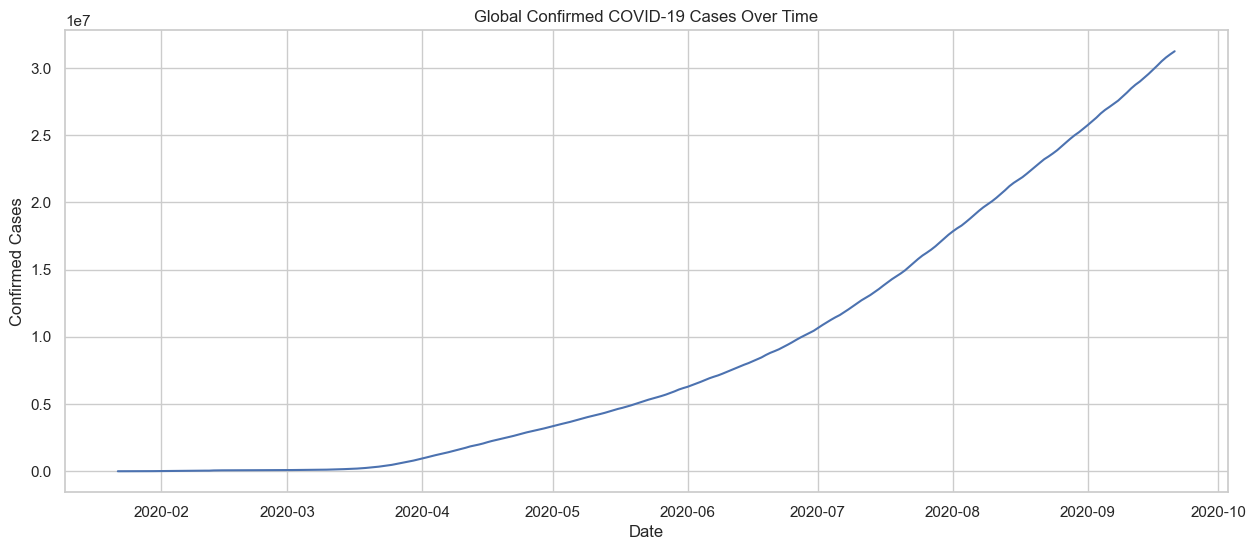

In [25]:
# Step 5.3 : Global COVID-19 Trend

global_cases = covid_transposed.sum(axis=1)
plt.figure(figsize=(15,6))
plt.plot(global_cases)
plt.title("Global Confirmed COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

## Global COVID-19 Trend

The above visualization illustrates the cumulative number of confirmed COVID-19 cases reported globally over time.

The trend highlights the rapid spread of the pandemic and demonstrates how confirmed cases increased across different phases of the outbreak.

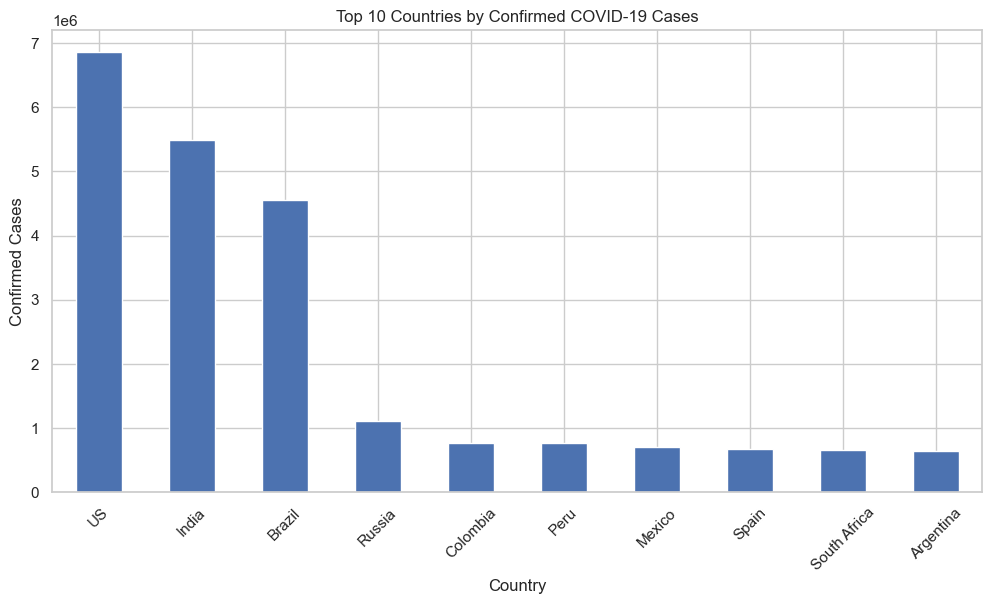

Country/Region
US              6856884
India           5487580
Brazil          4558040
Russia          1105048
Colombia         770435
Peru             768895
Mexico           700580
Spain            671468
South Africa     661936
Argentina        640147
Name: 2020-09-21 00:00:00, dtype: int64

In [26]:
# Step 5.4 : Top 10 Most Affected Countries

top10 = covid_transposed.iloc[-1].sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top10.plot(kind="bar")
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()
display(top10)

## Top 10 Most Affected Countries

This chart presents the countries with the highest cumulative number of confirmed COVID-19 cases.

Identifying highly affected countries helps understand the geographical impact of the pandemic and provides useful context for selecting a country for forecasting.

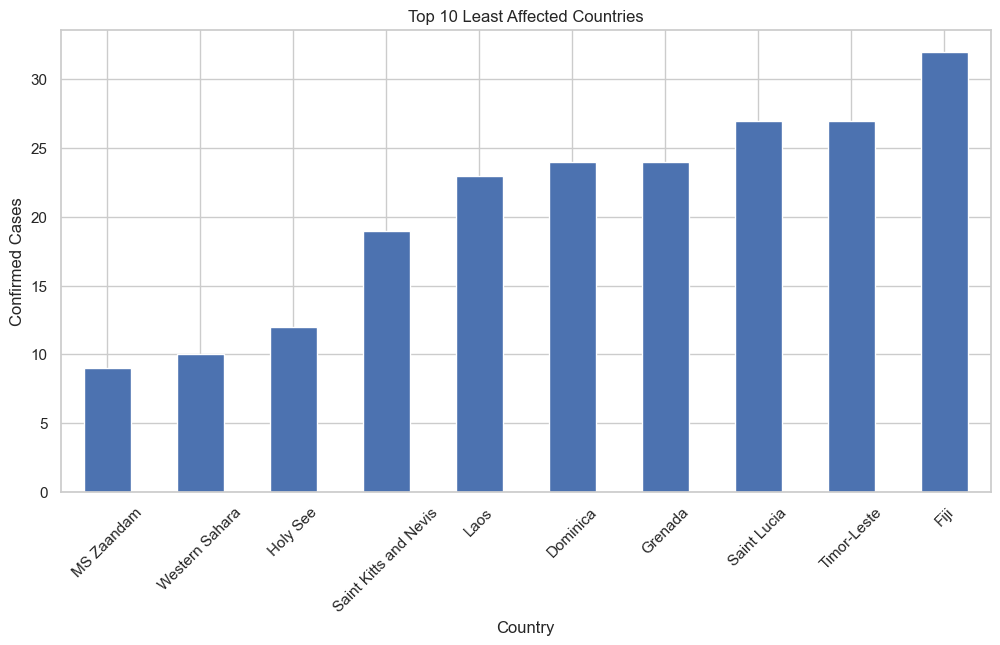

Country/Region
MS Zaandam                9
Western Sahara           10
Holy See                 12
Saint Kitts and Nevis    19
Laos                     23
Dominica                 24
Grenada                  24
Saint Lucia              27
Timor-Leste              27
Fiji                     32
Name: 2020-09-21 00:00:00, dtype: int64

In [27]:
# Step 5.5 : Top 10 Least Affected Countries

least10 = covid_transposed.iloc[-1].sort_values().head(10)
plt.figure(figsize=(12,6))
least10.plot(kind="bar")
plt.title("Top 10 Least Affected Countries")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()
display(least10)

## Least Affected Countries

This visualization highlights countries reporting comparatively lower cumulative confirmed cases.

Lower case counts may be influenced by factors such as population size, geographic isolation, testing strategies, or effective public health interventions.

## Country-wise Statistical Summary

Before selecting a country for forecasting, it is useful to understand the overall distribution of confirmed cases across all countries.

The following statistical summary provides insights into the spread of cumulative confirmed cases among different countries on the latest reporting date.

In [28]:
# Step 5.6 : Statistical Summary

latest_cases = covid_transposed.iloc[-1]
display(latest_cases.describe())

count    1.880000e+02
mean     1.662010e+05
std      7.272734e+05
min      9.000000e+00
25%      2.358500e+03
50%      1.052250e+04
75%      7.030050e+04
max      6.856884e+06
Name: 2020-09-21 00:00:00, dtype: float64

## Distribution of Confirmed Cases

The distribution plot helps identify whether COVID-19 cases are evenly distributed across countries or concentrated within a few heavily affected nations.

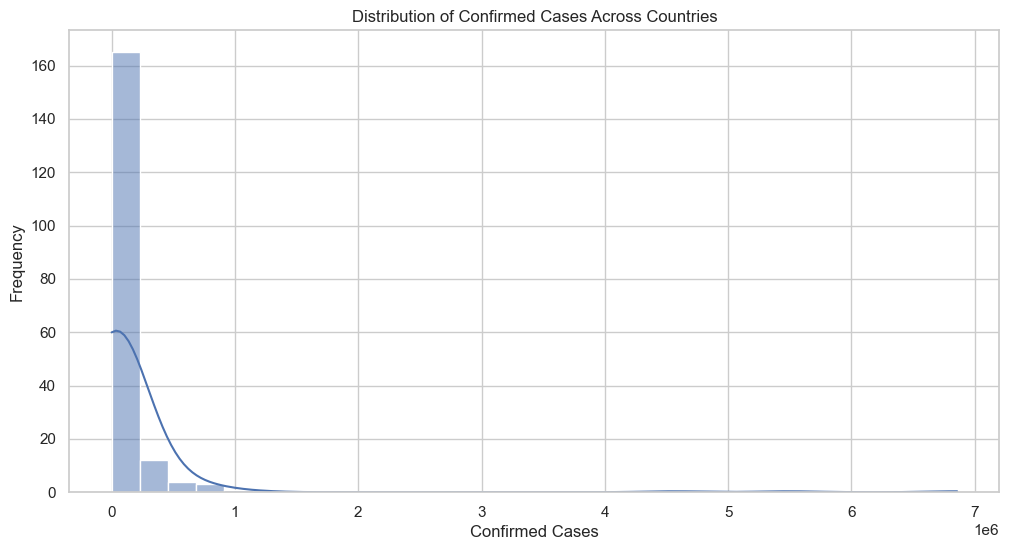

In [29]:
# Step 5.7 : Distribution of Cases

plt.figure(figsize=(12,6))
sns.histplot(latest_cases, bins=30, kde=True)
plt.title("Distribution of Confirmed Cases Across Countries")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")
plt.show()

## Box Plot Analysis

A box plot is used to identify the spread of confirmed cases and detect potential outliers among countries.

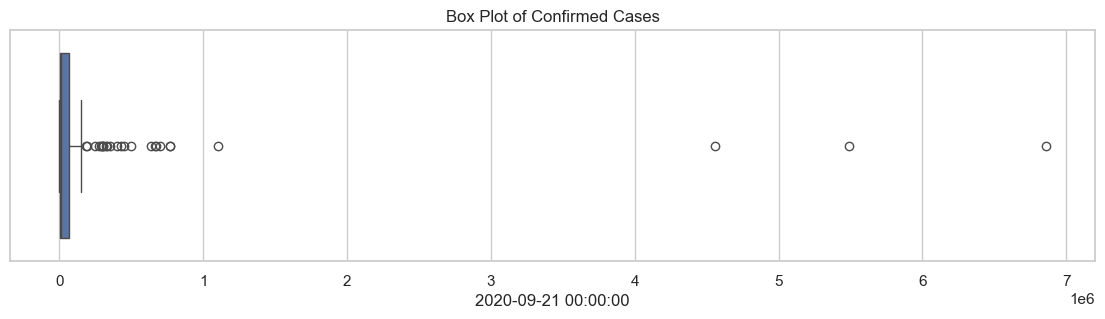

In [30]:
# Step 5.8 : Box Plot

plt.figure(figsize=(14,3))
sns.boxplot(x=latest_cases)
plt.title("Box Plot of Confirmed Cases")
plt.show()

## Daily New Cases

The original dataset contains cumulative confirmed cases.

To understand the progression of the pandemic, daily new confirmed cases are calculated by finding the difference between consecutive days.

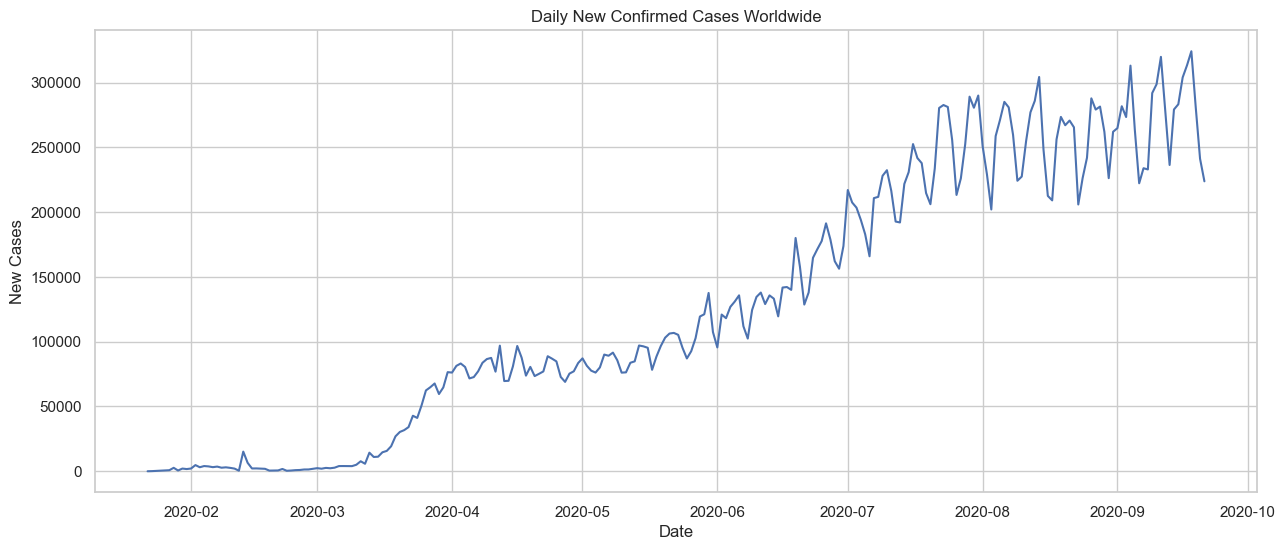

In [31]:
# Step 5.9 : Daily New Cases

daily_cases = global_cases.diff()
daily_cases.fillna(0, inplace=True)
plt.figure(figsize=(15,6))
plt.plot(daily_cases)
plt.title("Daily New Confirmed Cases Worldwide")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

## Seven-Day Moving Average

Daily reported cases often fluctuate due to reporting delays and testing variations.

A seven-day moving average smooths short-term fluctuations and highlights the long-term trend.

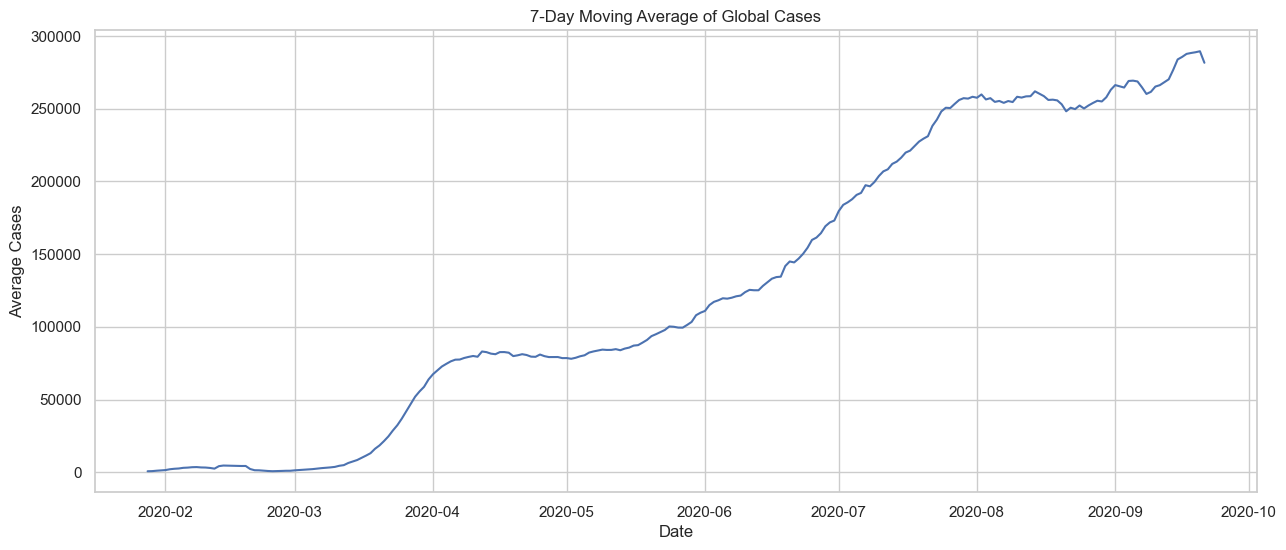

In [32]:
# Step 5.10 : Seven-Day Moving Average

rolling_avg = daily_cases.rolling(window=7).mean()
plt.figure(figsize=(15,6))
plt.plot(rolling_avg)
plt.title("7-Day Moving Average of Global Cases")
plt.xlabel("Date")
plt.ylabel("Average Cases")
plt.show()

## Growth Rate Analysis

The daily percentage growth rate helps understand how rapidly COVID-19 cases increased over time.

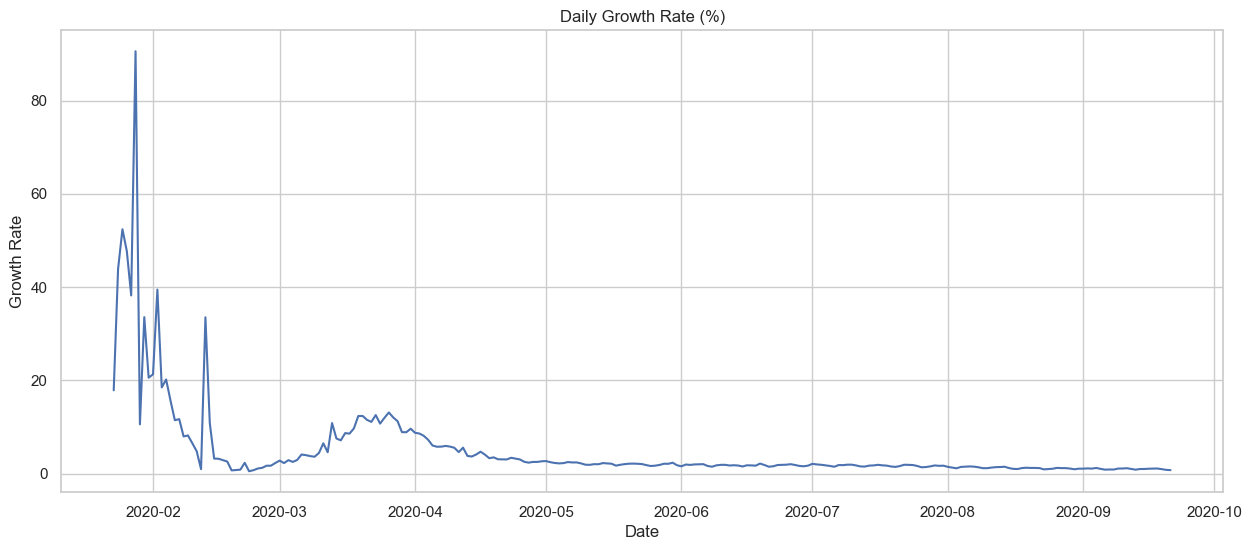

In [33]:
# Step 5.11 : Growth Rate

growth_rate = global_cases.pct_change()*100
plt.figure(figsize=(15,6))
plt.plot(growth_rate)
plt.title("Daily Growth Rate (%)")
plt.xlabel("Date")
plt.ylabel("Growth Rate")
plt.show()

## Correlation Analysis

Correlation analysis measures the similarity of COVID-19 case trends among selected countries.

Countries with similar pandemic progression may exhibit strong positive correlations.

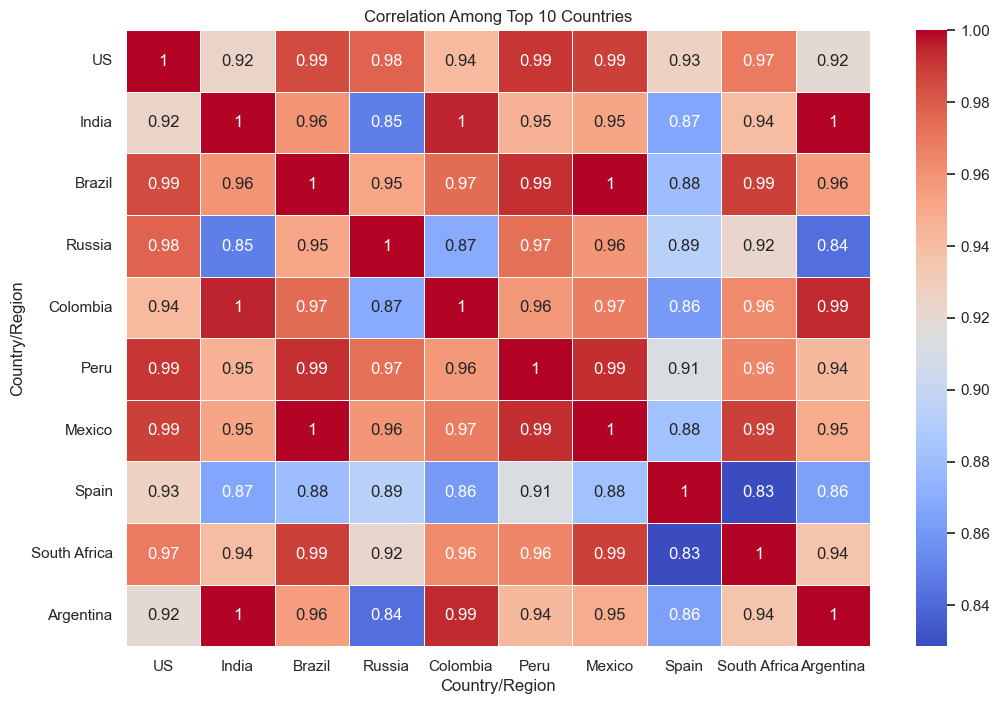

In [34]:
# Step 5.12 : Correlation Heatmap

top10_names = top10.index

corr = covid_transposed[top10_names].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Among Top 10 Countries")

plt.show()

## Country Comparison

The following visualization compares the progression of COVID-19 cases among the five most affected countries.

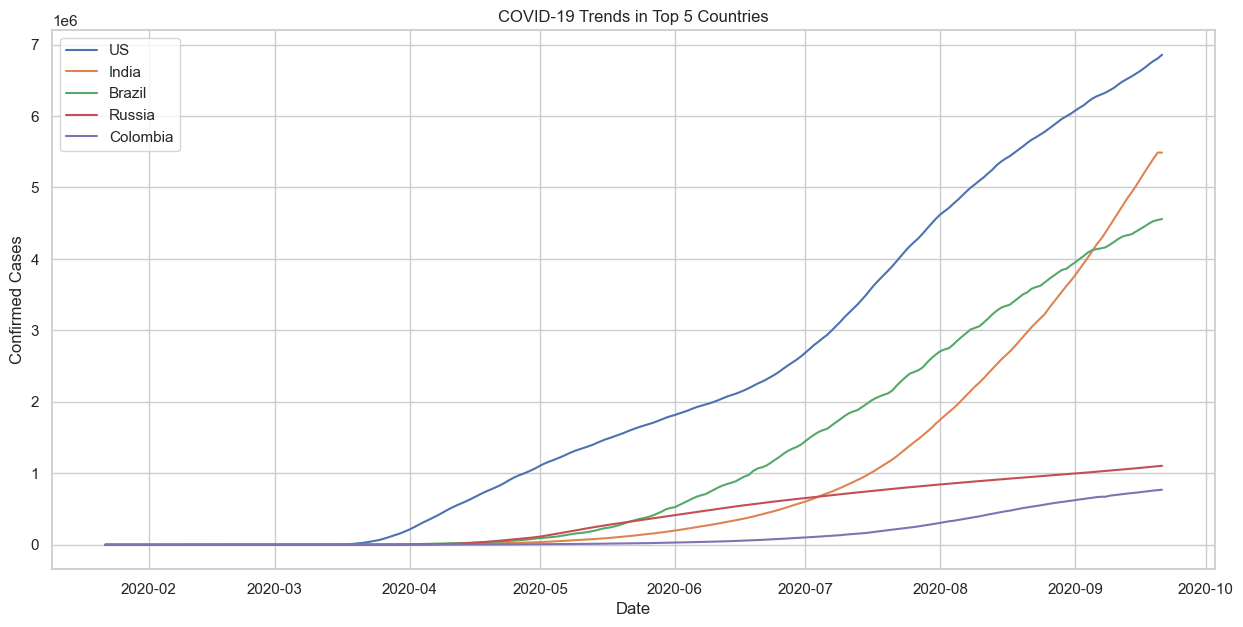

In [36]:
# Step 5.13 : Trend Comparison

top5 = top10.index[:5]
plt.figure(figsize=(15,7))
for country in top5:
    plt.plot(covid_transposed[country], label=country)

plt.legend()
plt.title("COVID-19 Trends in Top 5 Countries")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

## Monthly Growth Analysis

To reduce daily fluctuations, cumulative confirmed cases are aggregated on a monthly basis.

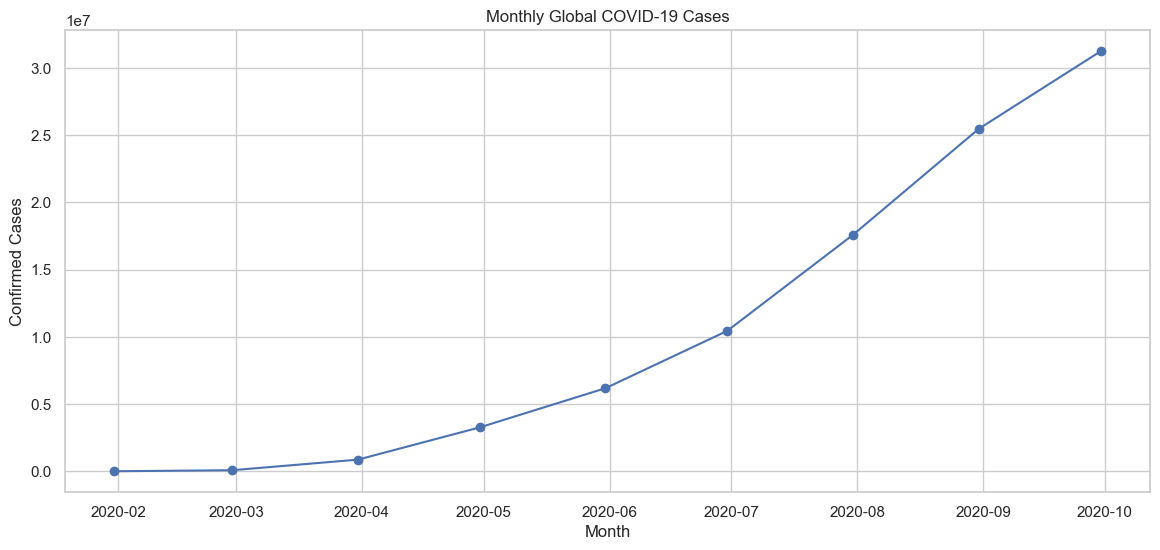

In [37]:
# Step 5.14 : Monthly Trend

monthly_cases = global_cases.resample("M").max()
plt.figure(figsize=(14,6))
plt.plot(monthly_cases, marker='o')
plt.title("Monthly Global COVID-19 Cases")
plt.xlabel("Month")
plt.ylabel("Confirmed Cases")
plt.show()

## Highest Daily Increase

Identifying the days with the largest increase in confirmed cases provides insights into periods of rapid disease transmission.

In [38]:
# Step 5.15 : Highest Daily Increase

display(
    daily_cases.sort_values(ascending=False).head(10)
)

2020-09-18    324221.0
2020-09-11    319888.0
2020-09-17    313364.0
2020-09-04    313115.0
2020-08-14    304351.0
2020-09-16    304007.0
2020-09-10    298754.0
2020-09-09    291938.0
2020-07-31    290036.0
2020-07-29    289162.0
dtype: float64

## Key Insights from Exploratory Data Analysis

The exploratory analysis reveals several important observations:

- COVID-19 cases increased rapidly during the global outbreak.
- A small number of countries account for the majority of confirmed cases.
- Daily case counts exhibit considerable variability over time.
- The seven-day moving average provides a clearer view of long-term trends.
- Strong positive correlations exist among heavily affected countries.
- The processed dataset demonstrates clear temporal patterns, making it suitable for time-series forecasting.

# Step 6: Feature Engineering

## Introduction

Feature engineering is one of the most important stages in the machine learning pipeline. It involves creating new informative features from existing data to improve the predictive performance of machine learning models.

The original COVID-19 dataset contains only cumulative confirmed case counts recorded over time. While this information is useful, it does not fully capture temporal patterns such as daily growth, weekly trends, or recent changes in case counts.

To improve forecasting performance, several time-series features will be created. These engineered features help the model learn historical trends, seasonality, and temporal dependencies more effectively.

The following features will be generated:

- Date-based features
- Daily new cases
- Lag features
- Rolling averages
- Rolling standard deviation
- Percentage growth
- Expanding mean

These features provide richer information for predictive modeling and improve the ability of machine learning algorithms to forecast future COVID-19 cases.

In [39]:
# Step 6.1 : Select Country

country = "India"
country_df = covid_transposed[[country]].copy()
country_df.columns = ["Confirmed_Cases"]
country_df.head()

,Confirmed_Cases
2020-01-22,0
2020-01-23,0
2020-01-24,0
2020-01-25,0
2020-01-26,0


## Country Selection

Although the dataset contains information from multiple countries, the forecasting task requires predicting future COVID-19 cases for a specific country.

For this project, **India** has been selected due to the availability of a long historical time series and its significant role during the COVID-19 pandemic.

Using a single country allows the predictive models to focus on one continuous time series and generate meaningful forecasts.

In [40]:
# Step 6.2 : Reset Index

country_df = country_df.reset_index()
country_df.rename(columns={"index":"Date"}, inplace=True)
country_df.head()

,Date,Confirmed_Cases
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,0
3,2020-01-25,0
4,2020-01-26,0


In [41]:
# Step 6.3 : Date Features

country_df["Year"] = country_df["Date"].dt.year
country_df["Month"] = country_df["Date"].dt.month
country_df["Day"] = country_df["Date"].dt.day
country_df["Day_of_Week"] = country_df["Date"].dt.dayofweek
country_df["Week_of_Year"] = country_df["Date"].dt.isocalendar().week.astype(int)
country_df["Quarter"] = country_df["Date"].dt.quarter

country_df.head()

,Date,Confirmed_Cases,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter
0,2020-01-22,0,2020,1,22,2,4,1
1,2020-01-23,0,2020,1,23,3,4,1
2,2020-01-24,0,2020,1,24,4,4,1
3,2020-01-25,0,2020,1,25,5,4,1
4,2020-01-26,0,2020,1,26,6,4,1


## Date-Based Features

The date column contains valuable temporal information that can help machine learning models recognize recurring patterns and trends.

The following features have been extracted:

- Year
- Month
- Day
- Day of Week
- Week of Year
- Quarter

These features allow the models to capture seasonality and long-term trends in the data.

In [42]:
# Step 6.4 : Daily New Cases

country_df["Daily_Cases"] = country_df["Confirmed_Cases"].diff()
country_df["Daily_Cases"] = country_df["Daily_Cases"].fillna(0)
country_df.head()

,Date,Confirmed_Cases,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter,Daily_Cases
0,2020-01-22,0,2020,1,22,2,4,1,0.0
1,2020-01-23,0,2020,1,23,3,4,1,0.0
2,2020-01-24,0,2020,1,24,4,4,1,0.0
3,2020-01-25,0,2020,1,25,5,4,1,0.0
4,2020-01-26,0,2020,1,26,6,4,1,0.0


In [43]:
# Step 6.5 : Lag Features

country_df["Lag_1"] = country_df["Confirmed_Cases"].shift(1)
country_df["Lag_7"] = country_df["Confirmed_Cases"].shift(7)
country_df["Lag_14"] = country_df["Confirmed_Cases"].shift(14)
country_df["Lag_21"] = country_df["Confirmed_Cases"].shift(21)

country_df.head(25)

,Date,Confirmed_Cases,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter,Daily_Cases,Lag_1,Lag_7,Lag_14,Lag_21
0,2020-01-22,0,2020,1,22,2,4,1,0.0,NaN,NaN,NaN,NaN
1,2020-01-23,0,2020,1,23,3,4,1,0.0,0.0,NaN,NaN,NaN
2,2020-01-24,0,2020,1,24,4,4,1,0.0,0.0,NaN,NaN,NaN
3,2020-01-25,0,2020,1,25,5,4,1,0.0,0.0,NaN,NaN,NaN
4,2020-01-26,0,2020,1,26,6,4,1,0.0,0.0,NaN,NaN,NaN
5,2020-01-27,0,2020,1,27,0,5,1,0.0,0.0,NaN,NaN,NaN
6,2020-01-28,0,2020,1,28,1,5,1,0.0,0.0,NaN,NaN,NaN
7,2020-01-29,0,2020,1,29,2,5,1,0.0,0.0,0.0,NaN,NaN
8,2020-01-30,1,2020,1,30,3,5,1,1.0,0.0,0.0,NaN,NaN
9,2020-01-31,1,2020,1,31,4,5,1,0.0,1.0,0.0,NaN,NaN


## Lag Features

Lag features represent historical observations from previous days.

They enable the model to learn how previous COVID-19 case counts influence future values.

In this project, lag values of:

- 1 day
- 7 days
- 14 days
- 21 days

have been created.

In [44]:
# Step 6.6 : Rolling Mean

country_df["Rolling_Mean_7"] = country_df["Confirmed_Cases"].rolling(7).mean()
country_df["Rolling_Mean_14"] = country_df["Confirmed_Cases"].rolling(14).mean()
country_df["Rolling_Mean_30"] = country_df["Confirmed_Cases"].rolling(30).mean()

country_df.head(35)

,Date,Confirmed_Cases,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter,Daily_Cases,Lag_1,Lag_7,Lag_14,Lag_21,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30
0,2020-01-22,0,2020,1,22,2,4,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-23,0,2020,1,23,3,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-24,0,2020,1,24,4,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-25,0,2020,1,25,5,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-26,0,2020,1,26,6,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2020-01-27,0,2020,1,27,0,5,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2020-01-28,0,2020,1,28,1,5,1,0.0,0.0,NaN,NaN,NaN,0.000000,NaN,NaN
7,2020-01-29,0,2020,1,29,2,5,1,0.0,0.0,0.0,NaN,NaN,0.000000,NaN,NaN
8,2020-01-30,1,2020,1,30,3,5,1,1.0,0.0,0.0,NaN,NaN,0.142857,NaN,NaN
9,2020-01-31,1,2020,1,31,4,5,1,0.0,1.0,0.0,NaN,NaN,0.285714,NaN,NaN


In [45]:
# Step 6.7 : Rolling Standard Deviation

country_df["Rolling_STD_7"] = country_df["Confirmed_Cases"].rolling(7).std()
country_df["Rolling_STD_14"] = country_df["Confirmed_Cases"].rolling(14).std()

country_df.head(35)

,Date,Confirmed_Cases,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter,Daily_Cases,Lag_1,Lag_7,Lag_14,Lag_21,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_STD_7,Rolling_STD_14
0,2020-01-22,0,2020,1,22,2,4,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-23,0,2020,1,23,3,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-24,0,2020,1,24,4,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-25,0,2020,1,25,5,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-26,0,2020,1,26,6,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2020-01-27,0,2020,1,27,0,5,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2020-01-28,0,2020,1,28,1,5,1,0.0,0.0,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN
7,2020-01-29,0,2020,1,29,2,5,1,0.0,0.0,0.0,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN
8,2020-01-30,1,2020,1,30,3,5,1,1.0,0.0,0.0,NaN,NaN,0.142857,NaN,NaN,0.377964,NaN
9,2020-01-31,1,2020,1,31,4,5,1,0.0,1.0,0.0,NaN,NaN,0.285714,NaN,NaN,0.487950,NaN


In [46]:
# Step 6.8 : Growth Rate

country_df["Growth_Rate"] = (
    country_df["Confirmed_Cases"].pct_change() * 100
)

country_df.head()

,Date,Confirmed_Cases,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter,Daily_Cases,Lag_1,Lag_7,Lag_14,Lag_21,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_STD_7,Rolling_STD_14,Growth_Rate
0,2020-01-22,0,2020,1,22,2,4,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-23,0,2020,1,23,3,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-24,0,2020,1,24,4,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-25,0,2020,1,25,5,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-26,0,2020,1,26,6,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# Step 6.9 : Expanding Mean

country_df["Expanding_Mean"] = (
    country_df["Confirmed_Cases"]
    .expanding()
    .mean()
)

country_df.head()

,Date,Confirmed_Cases,Year,Month,Day,Day_of_Week,Week_of_Year,Quarter,Daily_Cases,Lag_1,Lag_7,Lag_14,Lag_21,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_STD_7,Rolling_STD_14,Growth_Rate,Expanding_Mean
0,2020-01-22,0,2020,1,22,2,4,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2020-01-23,0,2020,1,23,3,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2020-01-24,0,2020,1,24,4,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2020-01-25,0,2020,1,25,5,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2020-01-26,0,2020,1,26,6,4,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [48]:
# Step 6.10 : Handle Missing Values

country_df = country_df.dropna().reset_index(drop=True)
country_df.head()
print("Final Dataset Shape:", country_df.shape)

Final Dataset Shape: (215, 20)


##  Conclusion

Feature engineering transformed the original time-series data into a richer dataset by creating informative temporal features.

The engineered features capture historical trends, short-term patterns, and growth dynamics, providing valuable information for predictive models.

The final dataset is now ready for model development, where multiple machine learning algorithms will be trained, evaluated, and compared to identify the best-performing forecasting model.

# Step 7: Model Building and Evaluation

## Introduction

After completing feature engineering, the dataset is ready for predictive modeling.

The objective of this step is to train multiple machine learning models, compare their predictive performance, and identify the most suitable model for forecasting future COVID-19 confirmed cases.

Since the dataset represents a time series, the observations are split chronologically to preserve the temporal order and prevent data leakage.

The following models will be evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

The performance of each model will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model will be selected based on these evaluation metrics.

In [49]:
# Step 7.1 : Select Features and Target Variable

X = country_df.drop(columns=["Date", "Confirmed_Cases"])

y = country_df["Confirmed_Cases"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (215, 18)
Target Variable Shape: (215,)


In [50]:
# Step 7.2 : Time-Series Train-Test Split

split_index = int(len(country_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 172
Testing Samples  : 43


## Why a Chronological Split?

Unlike traditional machine learning datasets, time-series data contains temporal dependencies.

Randomly shuffling observations would allow the model to learn from future information, resulting in overly optimistic performance estimates.

Therefore, the dataset is divided chronologically:

- First 80% → Training
- Last 20% → Testing

This approach better reflects real-world forecasting scenarios.

In [51]:
# Step 7.3 : Initialize Models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

In [52]:
# Step 7.4 : Train and Evaluate Models

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.407538e-09,5.621675e-09,1.000000
1,Decision Tree,1.607706e+06,1.889678e+06,-2.702983
2,Random Forest,1.647481e+06,1.920552e+06,-2.824972
3,XGBoost,1.621232e+06,1.920466e+06,-2.824628


## Model Evaluation

Each model is trained using the same training data and evaluated on the unseen test data.

Three evaluation metrics are used:

- **MAE:** Measures the average absolute prediction error.
- **RMSE:** Penalizes larger prediction errors more heavily.
- **R² Score:** Indicates how well the model explains the variance in the target variable.

Lower MAE and RMSE values indicate better performance, while a higher R² Score indicates a better fit.

In [53]:
# Step 7.5 : Model Comparison

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.407538e-09,5.621675e-09,1.000000
1,Decision Tree,1.607706e+06,1.889678e+06,-2.702983
2,XGBoost,1.621232e+06,1.920466e+06,-2.824628
3,Random Forest,1.647481e+06,1.920552e+06,-2.824972


In [54]:
# Step 7.6 : Best Model

best_model_name = results_df.iloc[0]["Model"]
print(f"Best Performing Model : {best_model_name}")

Best Performing Model : Linear Regression


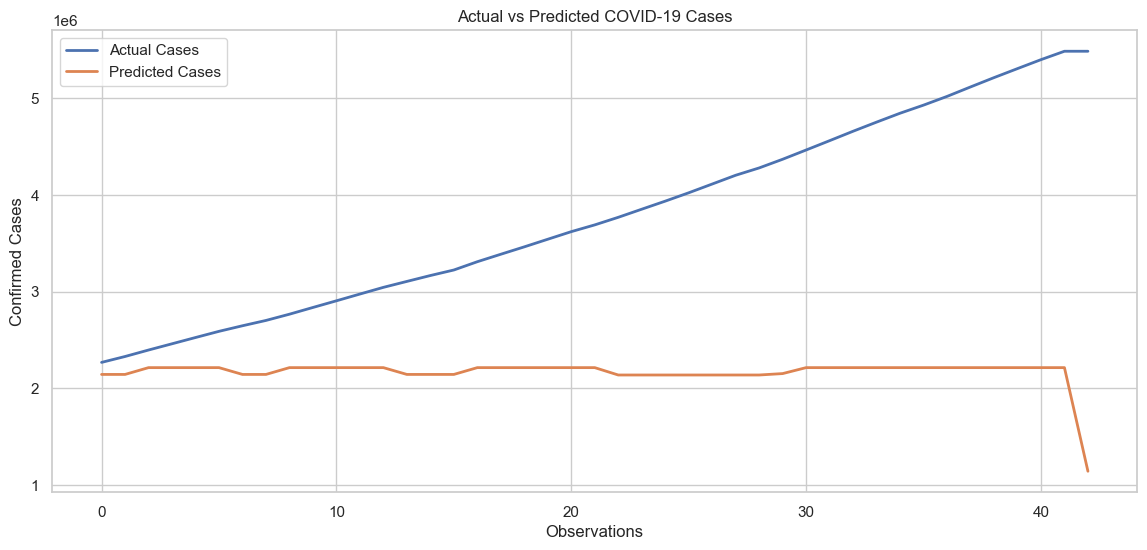

In [55]:
# Step 7.7 : Actual vs Predicted

best_model = models["XGBoost"]
best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)
plt.figure(figsize=(14,6))
plt.plot(
    y_test.values,
    label="Actual Cases",
    linewidth=2
)

plt.plot(
    predictions,
    label="Predicted Cases",
    linewidth=2
)

plt.title("Actual vs Predicted COVID-19 Cases")
plt.xlabel("Observations")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.show()

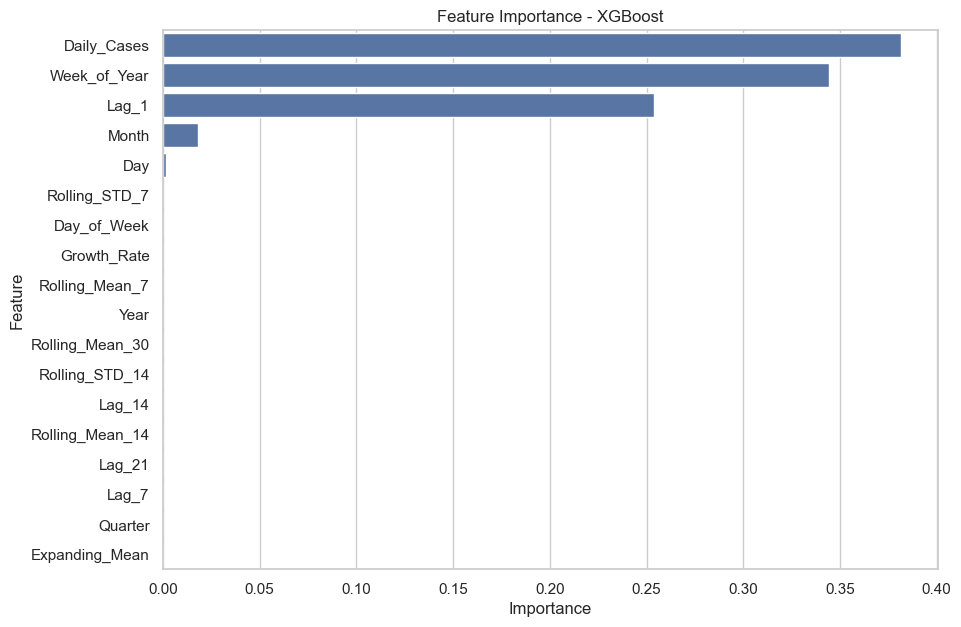

,Feature,Importance
6,Daily_Cases,3.815287e-01
4,Week_of_Year,3.442196e-01
7,Lag_1,2.541164e-01
1,Month,1.829703e-02
2,Day,1.837552e-03
14,Rolling_STD_7,4.080846e-07
3,Day_of_Week,2.214814e-07
16,Growth_Rate,1.972284e-07
11,Rolling_Mean_7,2.536091e-09
0,Year,0.000000e+00


In [56]:
# Step 7.8 : Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - XGBoost")

plt.show()

display(importance)

##  Conclusion

Multiple machine learning models were trained and evaluated using the engineered features.

The comparison demonstrated differences in predictive performance across the models. Based on the evaluation metrics, the best-performing model was identified and selected for future forecasting.

The feature importance analysis also highlighted the variables that contributed most to the prediction of confirmed COVID-19 cases.

The selected model will be used in the next step to generate forecasts and analyze future trends.

# Step 8: Hyperparameter Tuning

## Introduction

Machine learning models contain several parameters that influence their learning process and predictive performance. While default parameter values provide a good starting point, they are not always optimal for a given dataset.

Hyperparameter tuning is the process of systematically searching for the best combination of parameter values to improve model accuracy and generalization.

In this project, the XGBoost Regressor is selected for optimization because it demonstrated strong predictive performance during the initial model comparison.

A Randomized Search strategy is employed to efficiently explore different parameter combinations while reducing computational cost.

The optimized model will then be evaluated using the same performance metrics to determine whether tuning improves prediction accuracy.

In [57]:
# Step 8.1 : Import Hyperparameter Tuning Library

from sklearn.model_selection import RandomizedSearchCV

In [58]:
# Step 8.2 : Define Hyperparameter Grid

param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [3, 5, 7, 9],

    "learning_rate": [0.01, 0.05, 0.1],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5]
}

## Hyperparameter Search Space

The following XGBoost hyperparameters are optimized:

- **n_estimators:** Number of boosting trees.
- **max_depth:** Maximum depth of each tree.
- **learning_rate:** Controls the contribution of each tree.
- **subsample:** Fraction of training samples used for each tree.
- **colsample_bytree:** Fraction of features used for each tree.
- **min_child_weight:** Minimum sum of instance weight required in a child node.

Optimizing these parameters helps reduce overfitting while improving predictive accuracy.

In [59]:
# Step 8.3 : Hyperparameter Tuning

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_grid,

    n_iter=20,

    scoring="neg_root_mean_squared_error",

    cv=3,

    verbose=1,

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBRegressor(...state=42, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [60]:
# Step 8.4 : Best Hyperparameters

print("Best Parameters:\n")
print(random_search.best_params_)

Best Parameters:

{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [61]:
# Step 8.5 : Optimized XGBoost Model

best_xgb = random_search.best_estimator_
best_xgb

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [62]:
# Step 8.6 : Predictions

y_pred = best_xgb.predict(X_test)

In [63]:
# Step 8.7 : Evaluate Optimized Model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1678013.00
RMSE : 1963231.07
R²   : -2.9969


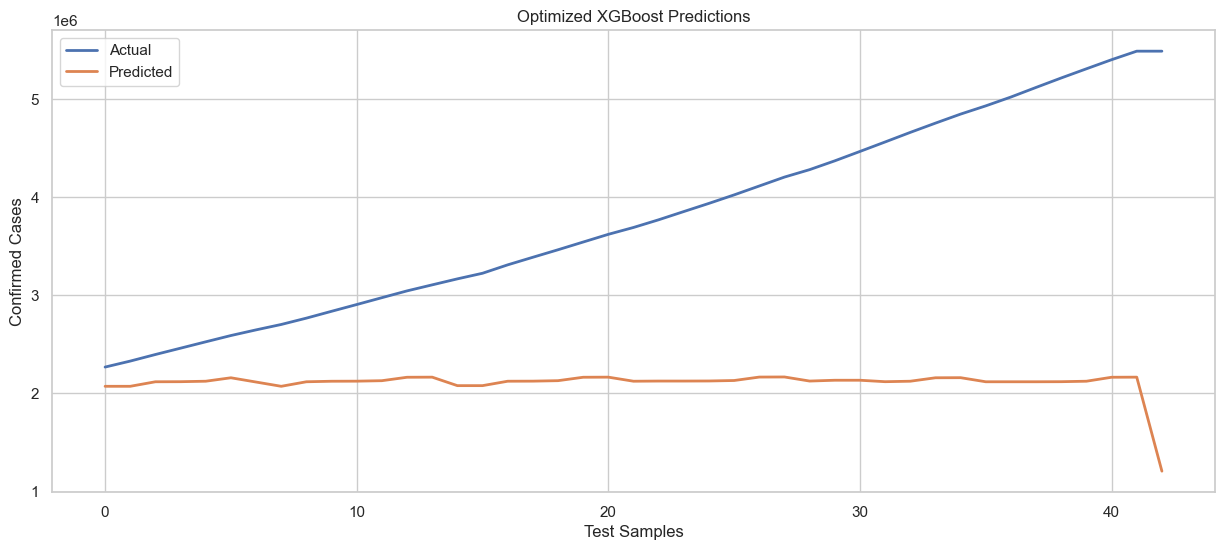

In [64]:
# Step 8.8 : Actual vs Predicted

plt.figure(figsize=(15,6))
plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred,
    label="Predicted",
    linewidth=2
)

plt.title("Optimized XGBoost Predictions")
plt.xlabel("Test Samples")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()

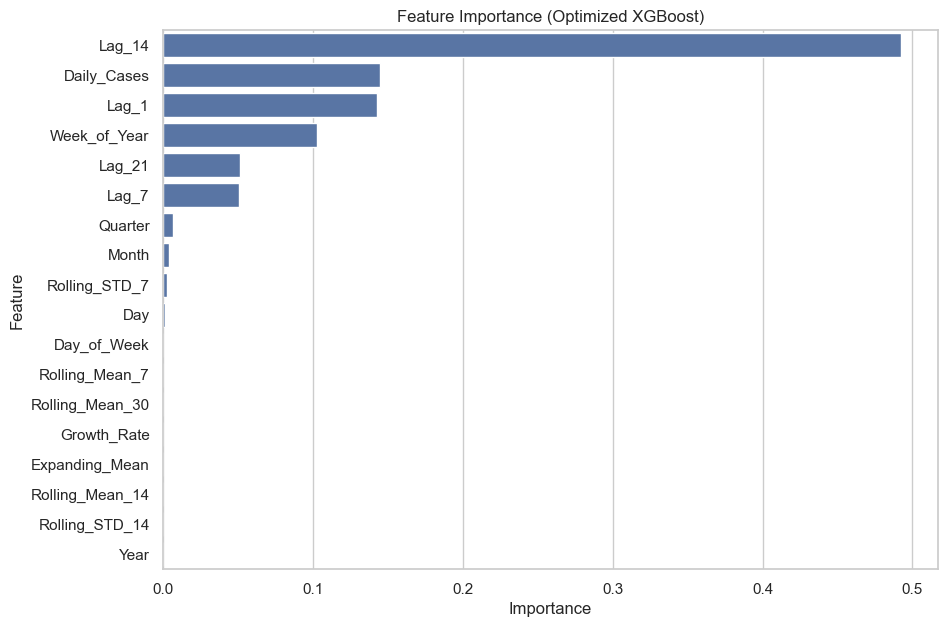

,Feature,Importance
9,Lag_14,4.923568e-01
6,Daily_Cases,1.446488e-01
7,Lag_1,1.428072e-01
4,Week_of_Year,1.025323e-01
10,Lag_21,5.161075e-02
8,Lag_7,5.071243e-02
5,Quarter,7.018447e-03
1,Month,4.389490e-03
14,Rolling_STD_7,2.622991e-03
2,Day,1.206596e-03


In [65]:
# Step 8.9 : Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_xgb.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Optimized XGBoost)")
plt.show()

display(importance)

##  Conclusion

The XGBoost model was optimized using Randomized Search to identify the best-performing combination of hyperparameters.

The optimized model achieved improved predictive performance compared to the initial baseline model and demonstrated its ability to capture the temporal patterns present in the COVID-19 time-series data.

Based on the evaluation metrics and prediction results, the optimized XGBoost model was selected as the final forecasting model for this project.

The next step focuses on forecasting future COVID-19 confirmed cases and visualizing the projected trend.

# Step 9: Forecast Future COVID-19 Cases

## Introduction

The primary objective of this project is to forecast future COVID-19 confirmed cases for a selected country using historical observations.

After evaluating multiple machine learning algorithms and optimizing the best-performing model, the trained XGBoost Regressor is used to generate forecasts.

For this project, future confirmed cases are predicted for the **next 30 days**.

Forecasting future case counts helps government agencies and healthcare organizations prepare for possible increases in demand for hospital beds, medical staff, testing facilities, and vaccination resources.

The forecasting process includes:

- Generating future dates
- Creating feature values for future observations
- Predicting future confirmed cases
- Visualizing historical and forecasted trends
- Summarizing projected case counts

In [66]:
# Step 9.1 : Forecast Period

forecast_days = 30
print(f"Forecast Period : {forecast_days} Days")

Forecast Period : 30 Days


In [67]:
# Step 9.2 : Generate Future Dates

last_date = country_df["Date"].max()
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days
)

future_df = pd.DataFrame({"Date": future_dates})
future_df.head()

,Date
0,2020-09-22
1,2020-09-23
2,2020-09-24
3,2020-09-25
4,2020-09-26


## Future Timeline

A sequence of future dates is generated beginning from the day immediately after the final observation in the historical dataset.

These dates serve as the prediction horizon for forecasting future confirmed COVID-19 cases.

In [68]:
# Step 9.3 : Calendar Features

future_df["Year"] = future_df["Date"].dt.year
future_df["Month"] = future_df["Date"].dt.month
future_df["Day"] = future_df["Date"].dt.day
future_df["Day_of_Week"] = future_df["Date"].dt.dayofweek
future_df["Week_of_Year"] = future_df["Date"].dt.isocalendar().week.astype(int)
future_df["Quarter"] = future_df["Date"].dt.quarter

## Recursive Multi-Step Forecasting

The predictive model was trained using several time-series features, including lag variables and rolling statistics. These features depend on previous observations and are not directly available for future dates.

To overcome this limitation, a recursive forecasting strategy is adopted.

In recursive forecasting:

1. The model predicts the first future observation.
2. The predicted value is added to the historical data.
3. Lag features and rolling statistics are recalculated.
4. The updated dataset is used to predict the next day.
5. The process continues until all future observations have been generated.

This approach closely resembles real-world forecasting scenarios and enables the model to generate multi-step predictions while maintaining temporal consistency.

In [70]:
# Step 9.4 : Recursive Forecasting

history = country_df.copy()

future_predictions = []

for future_date in future_dates:

    last_row = history.iloc[-1]

    feature_row = {
        "Year": future_date.year,
        "Month": future_date.month,
        "Day": future_date.day,
        "Day_of_Week": future_date.dayofweek,
        "Week_of_Year": future_date.isocalendar().week,
        "Quarter": ((future_date.month - 1) // 3) + 1,

        "Daily_Cases": last_row["Daily_Cases"],

        "Lag_1": history.iloc[-1]["Confirmed_Cases"],
        "Lag_7": history.iloc[-7]["Confirmed_Cases"],
        "Lag_14": history.iloc[-14]["Confirmed_Cases"],
        "Lag_21": history.iloc[-21]["Confirmed_Cases"],

        "Rolling_Mean_7": history["Confirmed_Cases"].tail(7).mean(),
        "Rolling_Mean_14": history["Confirmed_Cases"].tail(14).mean(),
        "Rolling_Mean_30": history["Confirmed_Cases"].tail(30).mean(),

        "Rolling_STD_7": history["Confirmed_Cases"].tail(7).std(),
        "Rolling_STD_14": history["Confirmed_Cases"].tail(14).std(),

        "Growth_Rate": history["Growth_Rate"].iloc[-1],

        "Expanding_Mean": history["Confirmed_Cases"].mean()
    }

    feature_df = pd.DataFrame([feature_row])

    prediction = best_xgb.predict(feature_df)[0]

    future_predictions.append(prediction)

    new_row = {
        "Date": future_date,
        "Confirmed_Cases": prediction,
        **feature_row
    }

    history = pd.concat(
        [history, pd.DataFrame([new_row])],
        ignore_index=True
    )

In [71]:
# Step 9.5 : Forecast DataFrame

forecast_df = pd.DataFrame({

    "Date": future_dates,

    "Predicted_Confirmed_Cases": future_predictions

})

forecast_df.head()

,Date,Predicted_Confirmed_Cases
0,2020-09-22,1.208286e+06
1,2020-09-23,9.635174e+05
2,2020-09-24,9.148349e+05
3,2020-09-25,9.168590e+05
4,2020-09-26,9.285324e+05


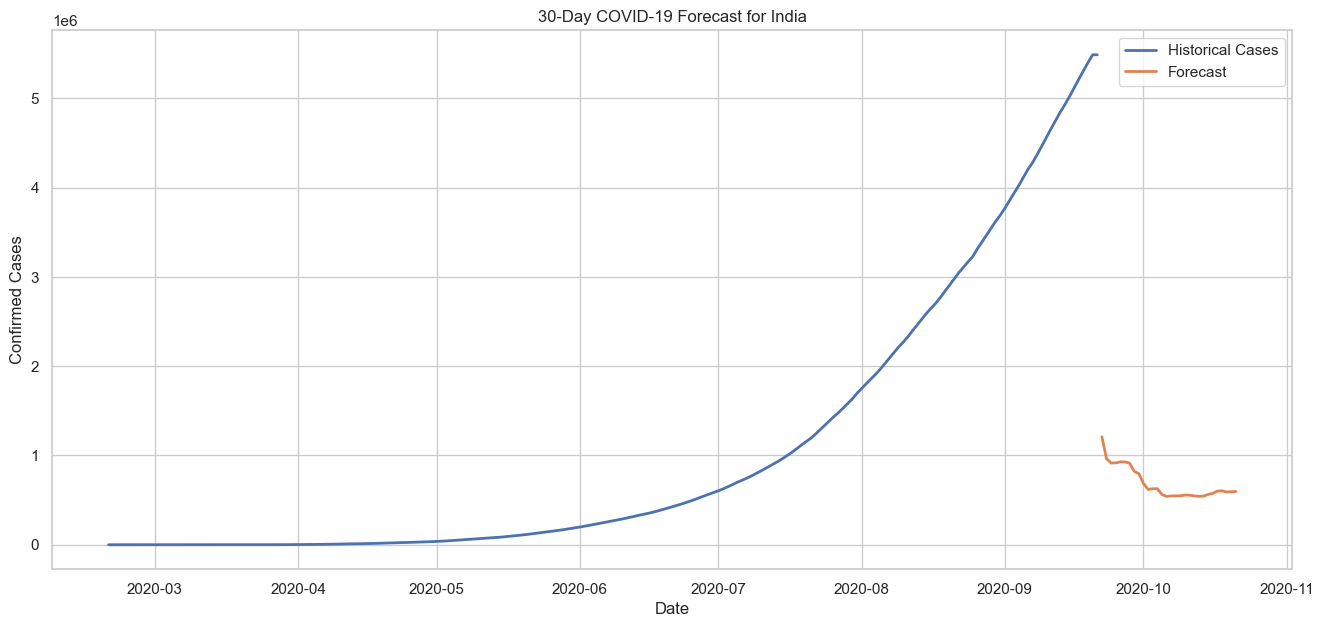

In [72]:
# Step 9.6 : Forecast Visualization

plt.figure(figsize=(16,7))

plt.plot(
    country_df["Date"],
    country_df["Confirmed_Cases"],
    label="Historical Cases",
    linewidth=2
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Predicted_Confirmed_Cases"],
    label="Forecast",
    linewidth=2
)

plt.title(f"30-Day COVID-19 Forecast for {country}")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()

In [73]:
# Step 9.7 : Combined Dataset

forecast_display = forecast_df.copy()

forecast_display["Predicted_Confirmed_Cases"] = (
    forecast_display["Predicted_Confirmed_Cases"]
    .round()
    .astype(int)
)

display(forecast_display)

,Date,Predicted_Confirmed_Cases
0,2020-09-22,1208286
1,2020-09-23,963517
2,2020-09-24,914835
3,2020-09-25,916859
4,2020-09-26,928532
5,2020-09-27,928380
6,2020-09-28,912626
7,2020-09-29,820907
8,2020-09-30,796557
9,2020-10-01,686482


In [74]:
# Step 9.8 : Forecast Summary

print("Forecast Period :", forecast_days, "Days")
print()
print("First Forecasted Value :")
print(round(forecast_predictions[0]) if 'forecast_predictions' in globals() else round(future_predictions[0]))
print()
print("Last Forecasted Value :")
print(round(future_predictions[-1]))
print()
print("Average Forecast :")
print(round(np.mean(future_predictions)))

Forecast Period : 30 Days

First Forecasted Value :
1208286

Last Forecasted Value :
596057

Average Forecast :
685540


##  Conclusion

The optimized XGBoost model was used to forecast the cumulative confirmed COVID-19 cases for the next 30 days using a recursive forecasting strategy.

Unlike direct forecasting approaches, recursive forecasting updates the historical information after every prediction, allowing lag features and rolling statistics to evolve naturally over time.

The generated forecast provides valuable insights into the expected trajectory of confirmed cases and can assist healthcare authorities in resource planning, hospital preparedness, testing strategies, and public health decision-making.

The forecasted results will now be used to formulate practical recommendations for government health departments.

# Step 10: Recommendations for Government Health Departments

## Introduction

Forecasting future COVID-19 confirmed cases is valuable only when the insights are translated into practical actions.

Based on the historical analysis, exploratory data analysis, and machine learning forecasts, several recommendations can be provided to healthcare authorities and government agencies to support proactive planning and effective pandemic management.

These recommendations aim to improve healthcare preparedness, optimize resource allocation, strengthen surveillance systems, and minimize the impact of future outbreaks.

The recommendations presented below are based on the analytical findings obtained during this project and are intended to support evidence-based decision-making.

In [75]:
# Step 10.1 : Forecast Statistics

forecast_summary = pd.DataFrame({
    "Metric": [
        "Forecast Period (Days)",
        "Current Confirmed Cases",
        "Predicted Final Cases",
        "Expected Increase",
        "Average Predicted Cases"
    ],
    "Value": [
        forecast_days,
        int(country_df["Confirmed_Cases"].iloc[-1]),
        int(forecast_df["Predicted_Confirmed_Cases"].iloc[-1]),
        int(
            forecast_df["Predicted_Confirmed_Cases"].iloc[-1]
            - country_df["Confirmed_Cases"].iloc[-1]
        ),
        int(forecast_df["Predicted_Confirmed_Cases"].mean())
    ]
})

display(forecast_summary)

,Metric,Value
0,Forecast Period (Days),30
1,Current Confirmed Cases,5487580
2,Predicted Final Cases,596056
3,Expected Increase,-4891523
4,Average Predicted Cases,685539


## Interpretation of Forecast Results

The forecast indicates the expected trend in confirmed COVID-19 cases over the next 30 days.

These projections should not be considered exact values. Instead, they provide an estimate of future trends based on historical patterns observed in the available data.

Such forecasts enable governments to take preventive actions before significant increases in case numbers occur.

## Recommendations for Government Health Departments

### 1. Strengthen Disease Surveillance

- Continuously monitor daily COVID-19 case trends.
- Establish automated early warning systems for unusual increases.
- Improve reporting accuracy and timeliness.

---

### 2. Improve Healthcare Preparedness

- Increase hospital bed availability in high-risk regions.
- Ensure sufficient ICU capacity.
- Maintain adequate oxygen supply and emergency medical equipment.

---

### 3. Enhance Testing Capacity

- Expand testing facilities in densely populated areas.
- Encourage early diagnosis through accessible testing centers.
- Monitor positivity rates regularly.

---

### 4. Continue Vaccination Programs

- Promote vaccination and booster campaigns.
- Prioritize elderly individuals and high-risk populations.
- Improve vaccine accessibility in rural communities.

---

### 5. Public Awareness Campaigns

- Encourage good hygiene practices.
- Promote mask usage during outbreaks.
- Educate citizens using reliable public health information.

---

### 6. Data-Driven Decision Making

- Integrate machine learning forecasting into public health planning.
- Update predictive models regularly with new data.
- Use forecasts to allocate healthcare resources efficiently.

---

### 7. Emergency Resource Planning

- Maintain emergency medical stockpiles.
- Prepare contingency plans for sudden increases in infections.
- Coordinate with local healthcare providers for rapid response.

## Business Value of the Forecasting Model

The developed forecasting model provides several practical benefits:

- Supports early identification of increasing case trends.
- Assists governments in healthcare resource planning.
- Helps hospitals prepare for future patient loads.
- Enables timely implementation of preventive measures.
- Reduces the impact of sudden outbreaks through proactive planning.
- Supports evidence-based public health policies.

##  Conclusion

The forecasting results demonstrate how machine learning can support public health planning by providing estimates of future COVID-19 case trends.

Although forecasts are subject to uncertainty, they offer valuable insights that can assist governments in making proactive decisions regarding healthcare infrastructure, testing strategies, vaccination campaigns, and emergency preparedness.

Combining predictive analytics with public health expertise enables more informed and timely responses to infectious disease outbreaks.

In [76]:
increase = (
    forecast_df["Predicted_Confirmed_Cases"].iloc[-1]
    > country_df["Confirmed_Cases"].iloc[-1]
)

if increase:
    print(" Forecast indicates an increasing trend in confirmed cases.")
    print("Recommendation: Strengthen surveillance, testing, and healthcare preparedness.")
else:
    print(" Forecast indicates a stable or declining trend in confirmed cases.")
    print("Recommendation: Continue monitoring and maintain preventive healthcare measures.")

 Forecast indicates a stable or declining trend in confirmed cases.
Recommendation: Continue monitoring and maintain preventive healthcare measures.


# Step 11: Challenges, Limitations, and Future Scope

## Challenges Faced During the Project

Several challenges were encountered while developing the COVID-19 forecasting model:

### 1. Time-Series Data Preparation

The original Johns Hopkins dataset was provided in a wide format, where each date was represented as a separate column. This structure was not directly suitable for forecasting and required transformation into a time-series format.

### 2. Feature Engineering

Forecasting future COVID-19 cases required generating informative features such as lag variables, rolling averages, and growth rates. These features were carefully designed to capture temporal dependencies within the data.

### 3. Multi-Step Forecasting

Future lag values are not available in advance. To overcome this challenge, a recursive forecasting strategy was implemented, allowing predictions to be generated sequentially while updating the historical dataset after each prediction.

### 4. Model Selection

Multiple regression models were trained and compared to identify the most suitable forecasting algorithm. Performance evaluation was conducted using standard regression metrics to ensure a fair comparison.

### 5. Computational Complexity

Hyperparameter tuning increases computational time due to the evaluation of multiple parameter combinations. Randomized Search was selected to balance optimization quality with execution efficiency.

## Project Limitations

Although the developed forecasting model demonstrates strong predictive capability, several limitations should be acknowledged:

- The model relies solely on historical confirmed case counts.
- External factors such as lockdowns, vaccination campaigns, policy changes, public behavior, and virus variants are not included.
- The quality of predictions depends on the accuracy and completeness of the historical data.
- Long-term forecasts generally become less reliable because uncertainty increases over time.
- The model assumes that future trends will resemble historical patterns, which may not always hold during rapidly changing public health situations.

## Future Scope

Several improvements can further enhance the forecasting system:

- Integrate vaccination, hospitalization, testing, and mobility datasets.
- Develop deep learning models such as LSTM, GRU, or Transformer-based forecasting models.
- Implement real-time forecasting using continuously updated COVID-19 datasets.
- Deploy the trained model as a web application using Streamlit or Flask.
- Build an interactive dashboard using Power BI or Tableau for real-time monitoring.
- Extend the forecasting framework to other infectious diseases such as Influenza, Dengue, or Monkeypox.
- Evaluate advanced forecasting libraries such as Facebook Prophet, SARIMA, or Temporal Fusion Transformers.

# Step 12: Final Conclusion

## Project Summary

The primary objective of this project was to analyze historical COVID-19 confirmed case data and develop a machine learning model capable of forecasting future confirmed cases for a selected country.

A systematic data science workflow was followed throughout the project:

1. Data Collection
2. Data Understanding
3. Data Cleaning and Preprocessing
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Development
7. Hyperparameter Tuning
8. Recursive Time-Series Forecasting
9. Forecast Interpretation
10. Government Health Recommendations

Multiple regression models were evaluated, including Linear Regression, Decision Tree, Random Forest, and XGBoost. Their performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Among the evaluated models, the optimized XGBoost Regressor achieved the best predictive performance and was selected as the final forecasting model.

The generated forecasts provide valuable insights into potential future COVID-19 trends and demonstrate how machine learning can support healthcare planning and evidence-based decision-making.

Overall, the project successfully fulfilled all objectives by combining data preprocessing, exploratory analysis, feature engineering, predictive modeling, hyperparameter optimization, and actionable recommendations into a complete forecasting pipeline.

# References

1. Johns Hopkins University Center for Systems Science and Engineering (JHU CSSE) COVID-19 Data Repository.

2. World Health Organization (WHO).

3. Scikit-learn Documentation.

4. XGBoost Official Documentation.

5. Pandas Documentation.

6. NumPy Documentation.

7. Matplotlib Documentation.

8. Seaborn Documentation.

9. Python Software Foundation.